# Main Pipeline FFNN
Pipeline ini berisi alur lengkap dari baca dataset sampai prediksi (tanpa EDA/feature engineering lanjutan):
1. Load data
2. Split train/val/test
3. Build config + model
4. Training
5. Evaluasi dan prediksi
6. Save/load model

# Import library

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().resolve()
if (PROJECT_ROOT / 'src').exists():
    SRC_PATH = PROJECT_ROOT / 'src'
elif (PROJECT_ROOT.parent / 'src').exists():
    SRC_PATH = PROJECT_ROOT.parent / 'src'
else:
    raise FileNotFoundError('Folder src tidak ditemukan dari working directory saat ini.')

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from modules.config import ModelConfig
from modules.ffnn import FFNN
from modules.activationfunction import Linear, Sigmoid, ReLU, Tanh, Softmax
from modules.lossfunction import BinaryCrossEntropy
from modules.weightinit import *
from utils.visualization import (
    plot_gradient_distribution,
    plot_weight_distribution,
    plot_loss_curves,
)

# Params

In [2]:
DATA_PATH = Path('../datasetml_2026.csv')
TARGET_COL = 'placement_status'

TEST_SIZE = 0.20
VAL_SIZE = 0.20
RANDOM_STATE = 42

DEFAULT_HIDDEN_DIMS = [32, 16]
DEFAULT_HIDDEN_ACTIVATIONS = ['ReLU', 'ReLU']
DEFAULT_OUTPUT_ACTIVATION = 'Sigmoid'
DEFAULT_LOSS = 'BinaryCrossEntropy'

DEFAULT_INITIALIZER = 'RandomNormalInitializer'
DEFAULT_INITIALIZER_PARAMS = {'mean': 0.0, 'variance': 0.01, 'seed': RANDOM_STATE}

MODEL_PARAMS = {
    'learning_rate': 0.001,
    'epochs': 100,
    'batch_size': 32,
    'verbose': 1,
    'regularization': 'l2',
    'reg_lambda': 0.01,
    'random_state': RANDOM_STATE,
}

HIDDEN_DIMS = DEFAULT_HIDDEN_DIMS
HIDDEN_ACTIVATION_CLASSES = DEFAULT_HIDDEN_ACTIVATIONS
OUTPUT_ACTIVATION_CLASS = DEFAULT_OUTPUT_ACTIVATION
LOSS_CLASS = DEFAULT_LOSS
INITIALIZER_CLASS = DEFAULT_INITIALIZER
INITIALIZER_PARAMS = DEFAULT_INITIALIZER_PARAMS

MODEL_PATH = Path('../models/ffnn_placement.pkl')
RUN_MODE = 1  # 1 = train, 2 = load

In [3]:
df = pd.read_csv(DATA_PATH)
print('Dataset shape:', df.shape)

X_df = df.drop(columns=[TARGET_COL]).copy()
y_raw = df[TARGET_COL].copy()

# one hot encoding for cat features
X_df = pd.get_dummies(X_df, drop_first=False)

label_map = {'Not Placed': 0, 'Placed': 1}

y_cat = y_raw 
y_all = y_raw.map(label_map).to_numpy(dtype=np.float64).reshape(-1, 1)

X_all = X_df.to_numpy(dtype=np.float64)
print('Feature matrix shape:', X_all.shape)
print('Target shape:', y_all.shape)

Dataset shape: (10000, 12)
Feature matrix shape: (10000, 28)
Target shape: (10000, 1)


In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_cat
)

strat_train = y_train_full.ravel()

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=strat_train
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print('Train:', X_train.shape, y_train.shape)
print('Val  :', X_val.shape, y_val.shape)
print('Test :', X_test.shape, y_test.shape)

Train: (6400, 28) (6400, 1)
Val  : (1600, 28) (1600, 1)
Test : (2000, 28) (2000, 1)


# Hyperparameter Testing

In [5]:

import re

from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.neural_network import MLPClassifier

# Konfigurasi default eksperimen hyperparameter.
BASE_MODEL_PARAMS = {
    **MODEL_PARAMS,
    'epochs': 80,
    'verbose': 0,
    'regularization': 'l1',
    'reg_lambda': 0.01,
}

ACTIVATION_CLASS_MAP = {
    'Linear': Linear,
    'Sigmoid': Sigmoid,
    'ReLU': ReLU,
    'Tanh': Tanh,
    'Softmax': Softmax,
}

TEST_DIR = PROJECT_ROOT
PLOT_DIRS = {
    'depthwidth': TEST_DIR / 'depthwidth',
    'activationfunc': TEST_DIR / 'activationfunc',
    'learningrate': TEST_DIR / 'learningrate',
    'regularization': TEST_DIR / 'regularization',
    'initializer': TEST_DIR / 'initializer',
    'sklearn': TEST_DIR / 'sklearnMLPcomparison',
    'rmsnorm': TEST_DIR / 'rmsnorm',
}
for out_dir in PLOT_DIRS.values():
    out_dir.mkdir(parents=True, exist_ok=True)


def _slugify(text):
    text = text.strip().lower()
    text = re.sub(r'[^a-z0-9]+', '_', text)
    return text.strip('_')


def train_and_evaluate(
    hidden_dims,
    hidden_activations,
    output_activation='Sigmoid',
    learning_rate=0.001,
    regularization='none',
    reg_lambda=0.01,
    epochs=80,
    batch_size=32,
    random_state=42,
    rmsnorm=False
):
    if len(hidden_dims) != len(hidden_activations):
        raise ValueError('Panjang hidden_dims dan hidden_activations harus sama.')

    input_dim = X_train.shape[1]
    output_dim = y_train.shape[1]
    layers_dims = [input_dim] + hidden_dims + [output_dim]

    hidden_activation_fns = [ACTIVATION_CLASS_MAP[name]() for name in hidden_activations]
    output_activation_fn = ACTIVATION_CLASS_MAP[output_activation]()
    activation_fns = hidden_activation_fns + [output_activation_fn]

    config = ModelConfig(
        layers_dims=layers_dims,
        activation_fn=activation_fns,
        loss_fn=BinaryCrossEntropy(),
        learning_rate=learning_rate,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        regularization=regularization,
        reg_lambda=reg_lambda,
        random_state=random_state,
        rmsnorm=rmsnorm,
    )

    initializer = RandomNormalInitializer(mean=0.0, variance=0.01, seed=random_state)
    model = FFNN(config, initializer)
    history = model.fit(X_train, y_train, X_val=X_val, y_val=y_val)

    y_pred_prob = model.forward(X_test).ravel()
    y_pred = (y_pred_prob >= 0.5).astype(int)
    y_true = y_test.ravel().astype(int)

    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }

    return {
        'model': model,
        'history': history,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_pred_prob': y_pred_prob,
        'metrics': metrics,
        'last_val_loss': history['val_loss'][-1] if history['val_loss'] else np.nan,
    }

def train_and_evaluate_initializer(
    initializer,
    hidden_dims,
    hidden_activations,
    output_activation='Sigmoid',
    learning_rate=0.001,
    regularization='none',
    reg_lambda=0.01,
    epochs=80,
    batch_size=32,
    random_state=42,
    rmsnorm=False
):
    if len(hidden_dims) != len(hidden_activations):
        raise ValueError('Panjang hidden_dims dan hidden_activations harus sama.')

    input_dim = X_train.shape[1]
    output_dim = y_train.shape[1]
    layers_dims = [input_dim] + hidden_dims + [output_dim]

    hidden_activation_fns = [ACTIVATION_CLASS_MAP[name]() for name in hidden_activations]
    output_activation_fn = ACTIVATION_CLASS_MAP[output_activation]()
    activation_fns = hidden_activation_fns + [output_activation_fn]

    config = ModelConfig(
        layers_dims=layers_dims,
        activation_fn=activation_fns,
        loss_fn=BinaryCrossEntropy(),
        learning_rate=learning_rate,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        regularization=regularization,
        reg_lambda=reg_lambda,
        random_state=random_state,
        rmsnorm=rmsnorm,
    )
    
    model = FFNN(config, initializer)
    history = model.fit(X_train, y_train, X_val=X_val, y_val=y_val)

    y_pred_prob = model.forward(X_test).ravel()
    y_pred = (y_pred_prob >= 0.5).astype(int)
    y_true = y_test.ravel().astype(int)

    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }

    return {
        'model': model,
        'history': history,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_pred_prob': y_pred_prob,
        'metrics': metrics,
        'last_val_loss': history['val_loss'][-1] if history['val_loss'] else np.nan,
    }


def metrics_table(results_dict):
    rows = []
    for name, result in results_dict.items():
        row = {'setting': name}
        row.update(result['metrics'])
        rows.append(row)
    return pd.DataFrame(rows).sort_values('accuracy', ascending=False).reset_index(drop=True)


def plot_distribution_comparison(results_dict, layer_indices=None, title='', output_dir=None, file_prefix='distribution'):
    if layer_indices is None:
        layer_indices = [0]

    if title:
        print(f'=== {title} ===')

    for name, result in results_dict.items():
        safe_name = _slugify(name)
        weight_path = None
        grad_path = None

        if output_dir is not None:
            weight_path = output_dir / f'{file_prefix}_{safe_name}_weight.png'
            grad_path = output_dir / f'{file_prefix}_{safe_name}_gradient.png'

        print(f'\n[{name}] Weight Distribution')
        plot_weight_distribution(result['model'], layer_indices=layer_indices, save_path=weight_path)
        print(f'[{name}] Gradient Distribution')
        plot_gradient_distribution(result['model'], layer_indices=layer_indices, save_path=grad_path)


def show_prediction_sample(results_dict, n=5):
    sample = pd.DataFrame({'y_true': y_test.ravel().astype(int)[:n]})
    for name, result in results_dict.items():
        sample[f'pred_{name}'] = result['y_pred'][:n]
    return sample

## 1) Pengaruh Depth dan Width

- 3 variasi **width** (depth tetap).
- 3 variasi **depth** (width semua layer tetap).
- Dibandingkan: hasil prediksi akhir + grafik train/val loss.

=== Width Experiment Metrics ===


,setting,accuracy,precision,recall,f1
0,"W3_[64,64,64]",0.7475,0.754558,0.874086,0.809936
1,"W2_[32,32,32]",0.6470,0.637076,0.991064,0.775588
2,"W1_[16,16,16]",0.6155,0.615500,1.000000,0.761993



Sample prediksi:


,y_true,"pred_W1_[16,16,16]","pred_W2_[32,32,32]","pred_W3_[64,64,64]"
0,0,1,1,0
1,0,1,0,0
2,0,1,1,1
3,0,1,1,0
4,1,1,1,1


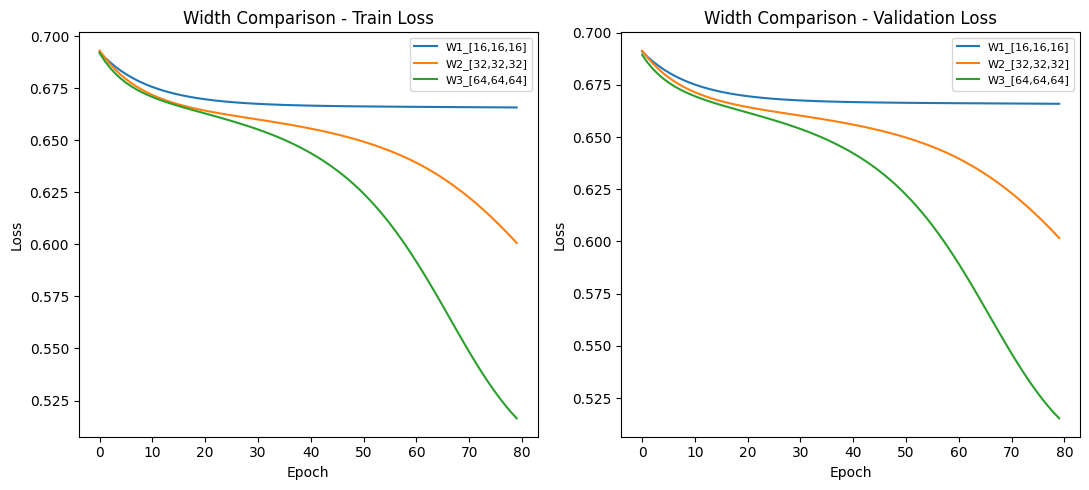

=== Depth Experiment Metrics ===


,setting,accuracy,precision,recall,f1
0,D1_[64],0.7565,0.771533,0.858652,0.812764
1,"D2_[64,64]",0.7525,0.770987,0.850528,0.808806
2,"D3_[64,64,64]",0.7475,0.754558,0.874086,0.809936



Sample prediksi:


,y_true,pred_D1_[64],"pred_D2_[64,64]","pred_D3_[64,64,64]"
0,0,0,0,0
1,0,0,0,0
2,0,1,1,1
3,0,0,1,0
4,1,1,1,1


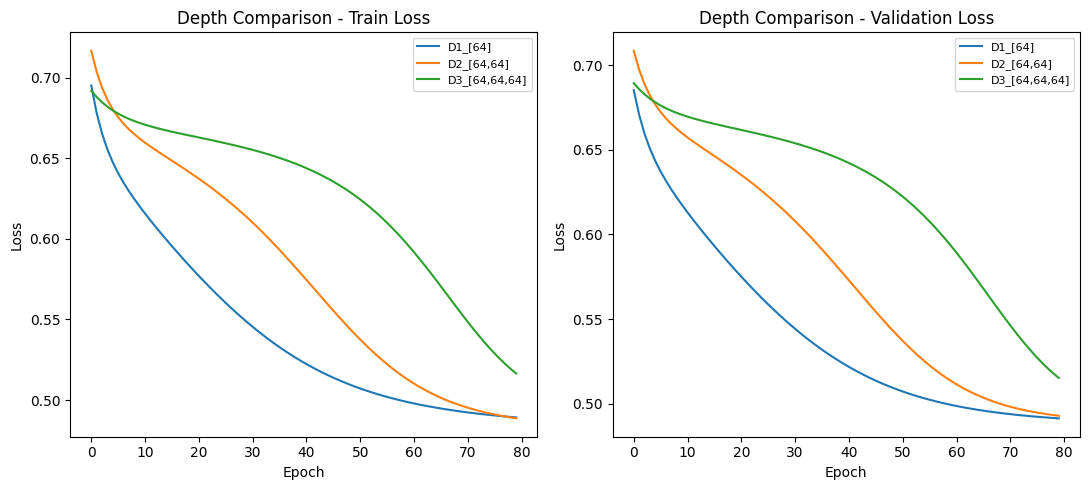

In [6]:
# 1A. Variasi width
width_settings = {
    'W1_[16,16,16]': [16, 16, 16],
    'W2_[32,32,32]': [32, 32, 32],
    'W3_[64,64,64]': [64, 64, 64],
}

width_results = {}
for name, dims in width_settings.items():
    width_results[name] = train_and_evaluate(
        hidden_dims=dims,
        hidden_activations=['ReLU', 'ReLU', 'ReLU'],
        learning_rate=BASE_MODEL_PARAMS['learning_rate'],
        regularization='none',
        reg_lambda=0.0,
        epochs=BASE_MODEL_PARAMS['epochs'],
        batch_size=BASE_MODEL_PARAMS['batch_size'],
        random_state=RANDOM_STATE,
    )

print('=== Width Experiment Metrics ===')
display(metrics_table(width_results))
print('\nSample prediksi:')
display(show_prediction_sample(width_results, n=5))
plot_loss_curves(
    width_results,
    'Width Comparison',
    save_path=PLOT_DIRS['depthwidth'] / 'width_loss_curves.png',
)

# 1B. Variasi depth (width tetap = 64 di setiap hidden layer)
depth_settings = {
    'D1_[64]': [64],
    'D2_[64,64]': [64, 64],
    'D3_[64,64,64]': [64, 64, 64],
}

depth_results = {}
for name, dims in depth_settings.items():
    depth_results[name] = train_and_evaluate(
        hidden_dims=dims,
        hidden_activations=['ReLU'] * len(dims),
        learning_rate=BASE_MODEL_PARAMS['learning_rate'],
        regularization='none',
        reg_lambda=0.0,
        epochs=BASE_MODEL_PARAMS['epochs'],
        batch_size=BASE_MODEL_PARAMS['batch_size'],
        random_state=RANDOM_STATE,
    )

print('=== Depth Experiment Metrics ===')
display(metrics_table(depth_results))
print('\nSample prediksi:')
display(show_prediction_sample(depth_results, n=5))
plot_loss_curves(
    depth_results,
    'Depth Comparison',
    save_path=PLOT_DIRS['depthwidth'] / 'depth_loss_curves.png',
)

## 2) Pengaruh Fungsi Aktivasi Hidden Layer

Base arsitektur minimal 3 hidden layer: `[32, 32, 16]`.
Layer yang diuji: hidden layer ke-2 (index 1 pada hidden layers).

Aktivasi yang dicoba: `Linear`, `Sigmoid`, `ReLU`, `Tanh` (tanpa `Softmax`).

=== Activation Experiment Metrics ===


,setting,accuracy,precision,recall,f1
0,Layer2=Tanh,0.7480,0.776426,0.829407,0.802042
1,Layer2=ReLU,0.7475,0.754558,0.874086,0.809936
2,Layer2=Linear,0.7470,0.775665,0.828595,0.801257
3,Layer2=Sigmoid,0.6155,0.615500,1.000000,0.761993



Sample prediksi:


,y_true,pred_Layer2=Linear,pred_Layer2=Sigmoid,pred_Layer2=ReLU,pred_Layer2=Tanh
0,0,0,1,0,0
1,0,0,1,0,0
2,0,1,1,1,1
3,0,0,1,0,0
4,1,1,1,1,1


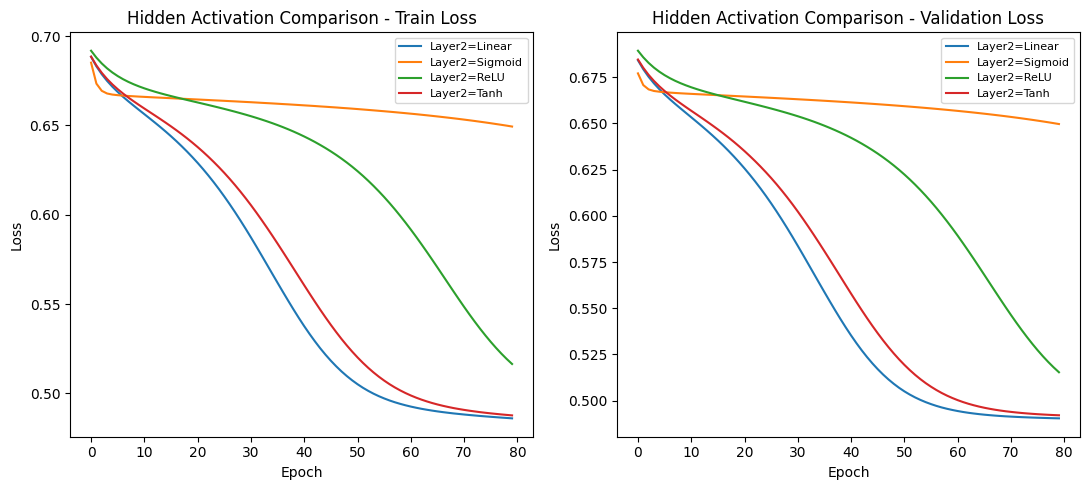

=== Activation - Weight & Gradient Distribution (Layers 0,1,2) ===

[Layer2=Linear] Weight Distribution


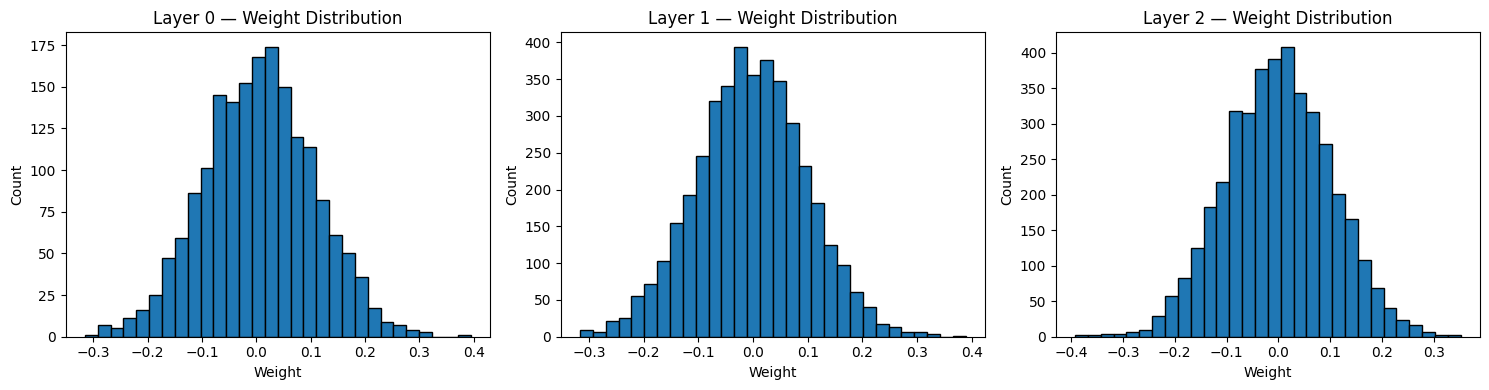

[Layer2=Linear] Gradient Distribution


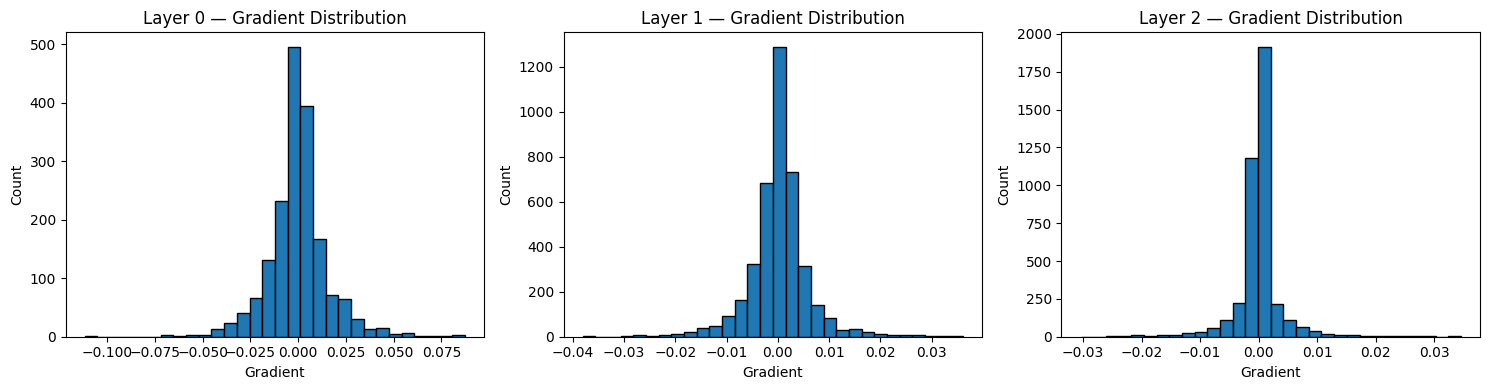


[Layer2=Sigmoid] Weight Distribution


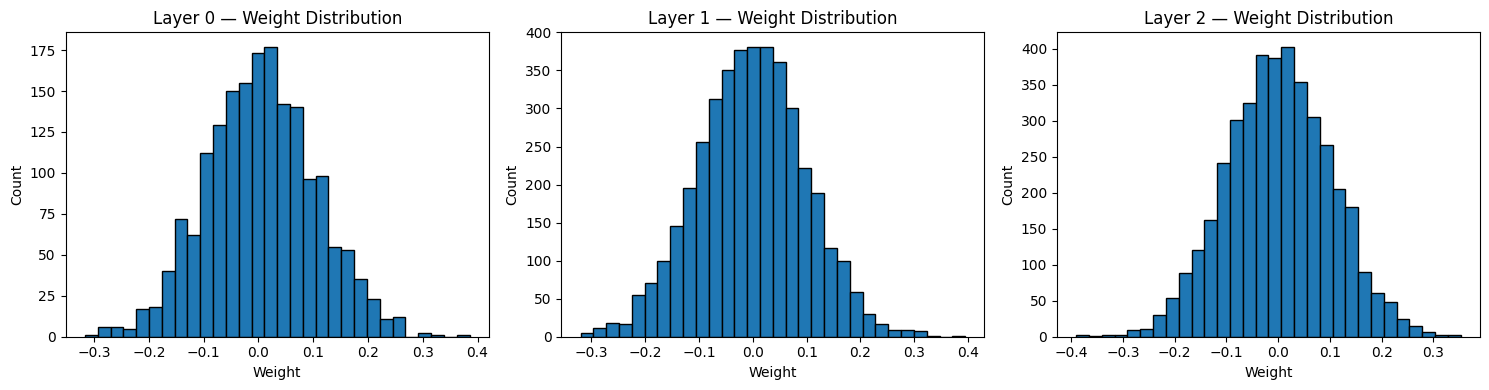

[Layer2=Sigmoid] Gradient Distribution


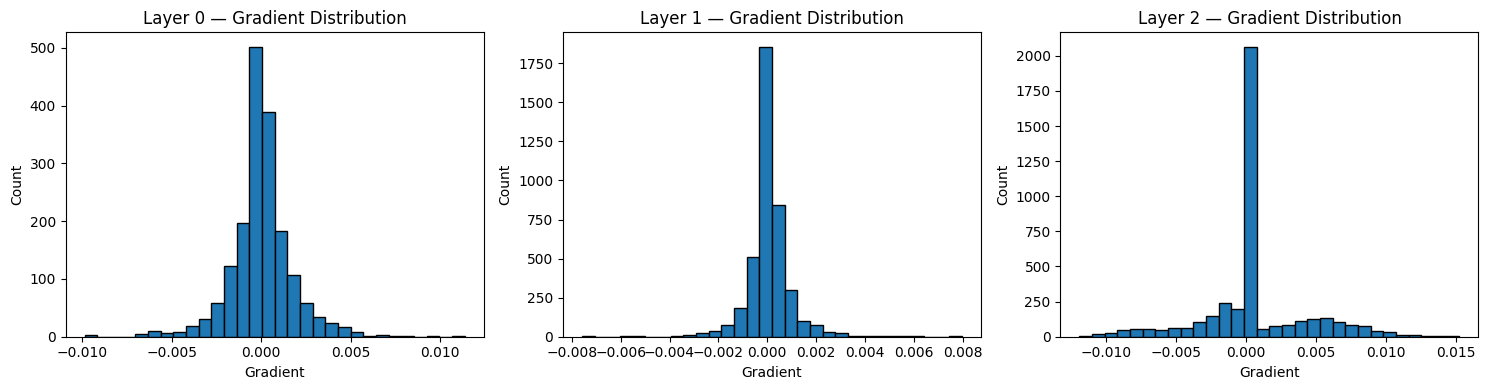


[Layer2=ReLU] Weight Distribution


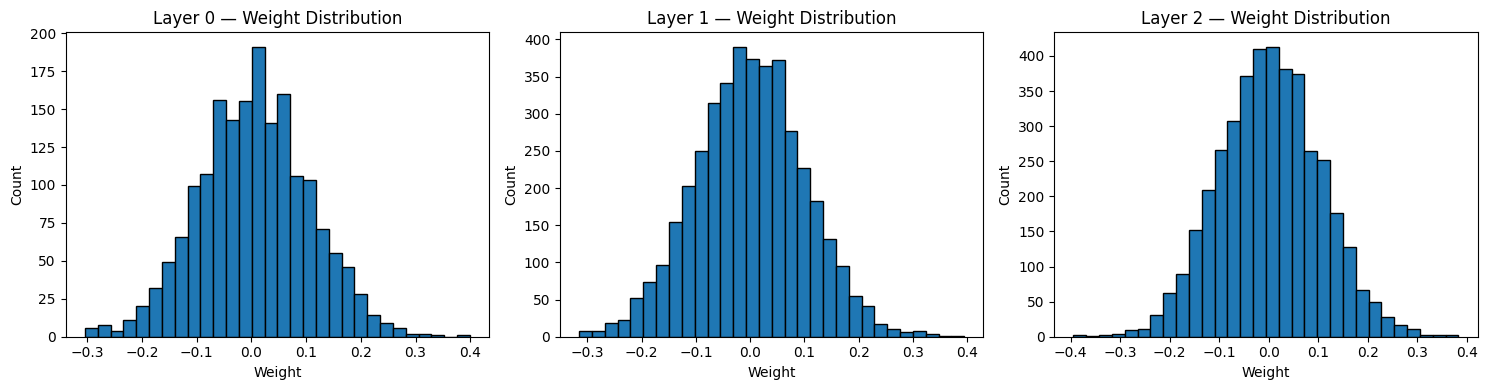

[Layer2=ReLU] Gradient Distribution


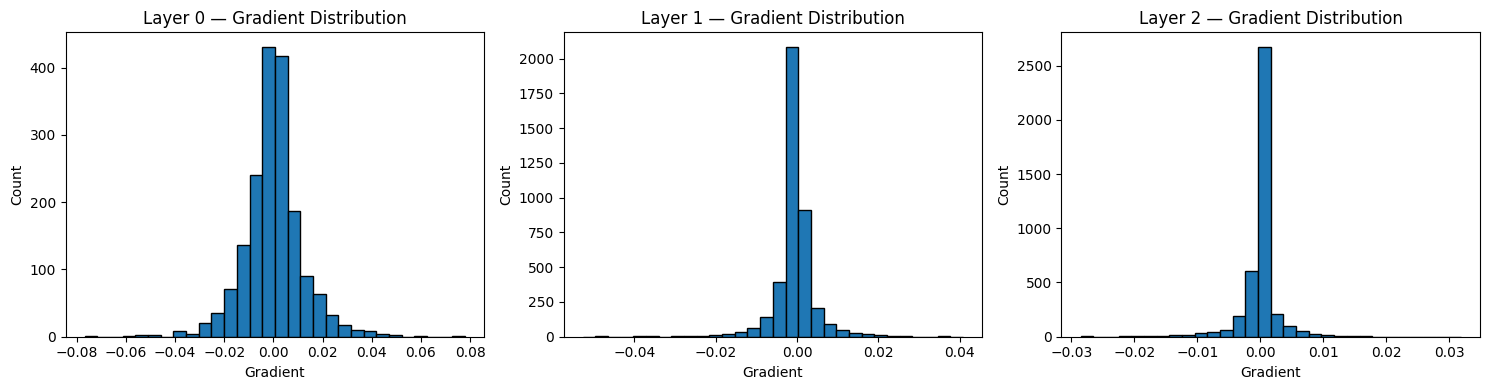


[Layer2=Tanh] Weight Distribution


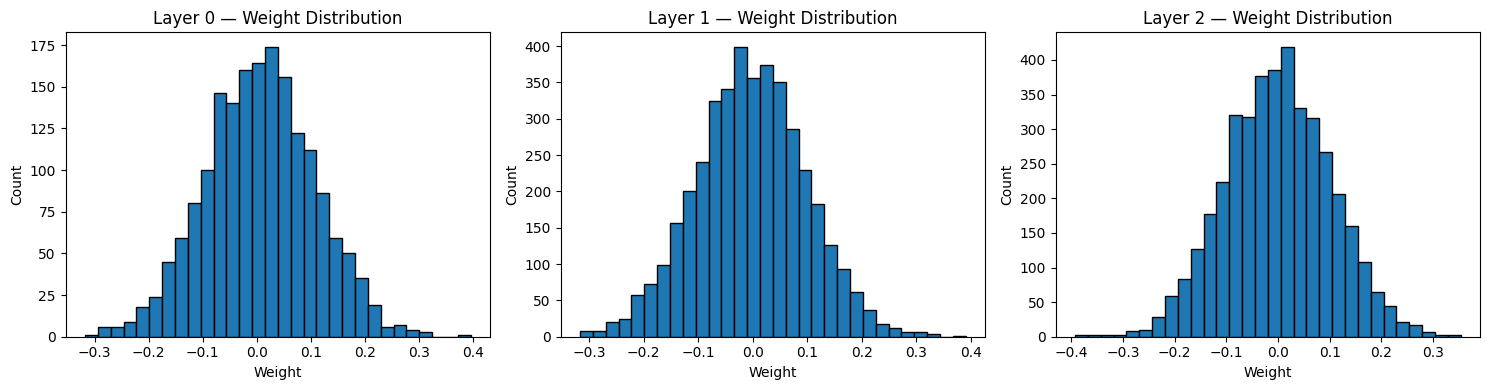

[Layer2=Tanh] Gradient Distribution


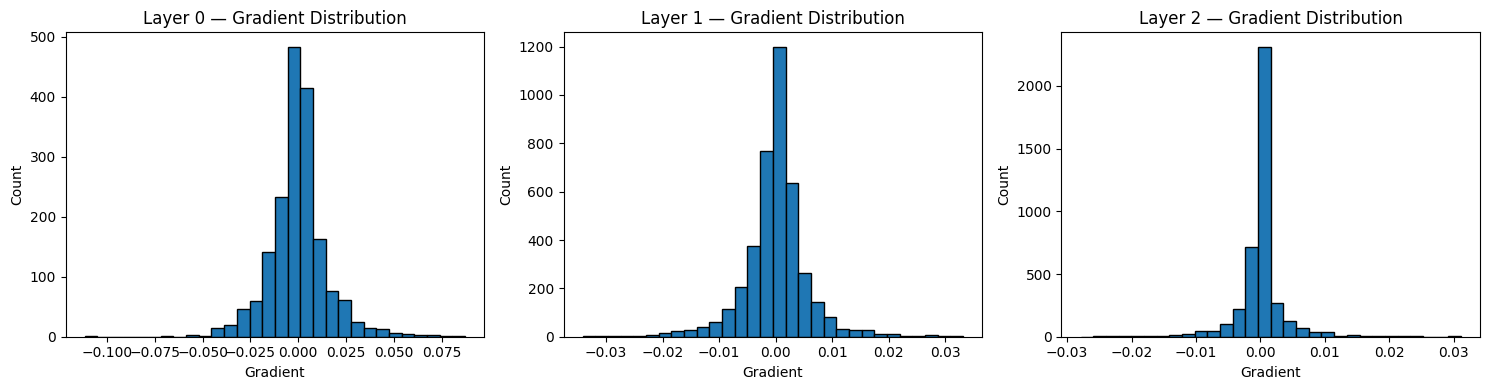

In [7]:
base_hidden_dims = [64, 64, 64]
base_hidden_acts = ['ReLU', 'ReLU', 'ReLU']
activation_candidates = ['Linear', 'Sigmoid', 'ReLU', 'Tanh']
activation_results = {}

for act in activation_candidates:
    test_acts = base_hidden_acts.copy()
    test_acts[1] = act  # layer pengujian

    key = f'Layer2={act}'
    activation_results[key] = train_and_evaluate(
        hidden_dims=base_hidden_dims,
        hidden_activations=test_acts,
        learning_rate=BASE_MODEL_PARAMS['learning_rate'],
        regularization='none',
        reg_lambda=0.0,
        epochs=BASE_MODEL_PARAMS['epochs'],
        batch_size=BASE_MODEL_PARAMS['batch_size'],
        random_state=RANDOM_STATE,
    )

print('=== Activation Experiment Metrics ===')
display(metrics_table(activation_results))
print('\nSample prediksi:')
display(show_prediction_sample(activation_results, n=5))
plot_loss_curves(
    activation_results,
    'Hidden Activation Comparison',
    save_path=PLOT_DIRS['activationfunc'] / 'activation_loss_curves.png',
)

plot_distribution_comparison(
    activation_results,
    layer_indices=[0, 1, 2],
    title='Activation - Weight & Gradient Distribution (Layers 0,1,2)',
    output_dir=PLOT_DIRS['activationfunc'],
    file_prefix='activation_layers012',
)

## 3) Pengaruh Learning Rate

3 variasi learning rate dan perbandingan:
- hasil akhir prediksi,
- train/validation loss per epoch,
- distribusi bobot serta gradien bobot.

=== Learning Rate Experiment Metrics ===


,setting,accuracy,precision,recall,f1
0,lr=0.001,0.7475,0.754558,0.874086,0.809936
1,lr=0.005,0.7380,0.772973,0.813160,0.792557
2,lr=0.0005,0.6155,0.615500,1.000000,0.761993



Sample prediksi:


,y_true,pred_lr=0.0005,pred_lr=0.001,pred_lr=0.005
0,0,1,0,0
1,0,1,0,0
2,0,1,1,1
3,0,1,0,0
4,1,1,1,1


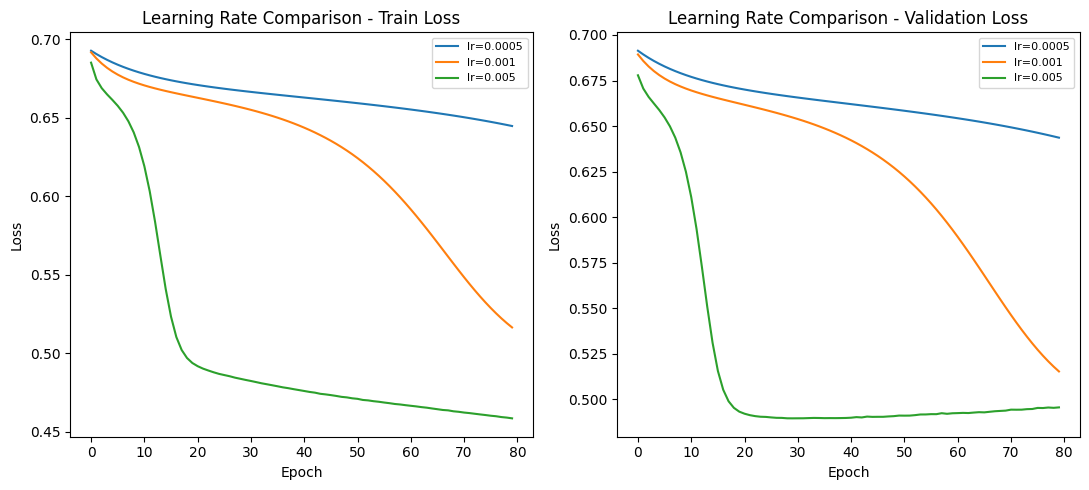

=== Learning Rate - Weight & Gradient Distribution (Layers 0,1,2) ===

[lr=0.0005] Weight Distribution


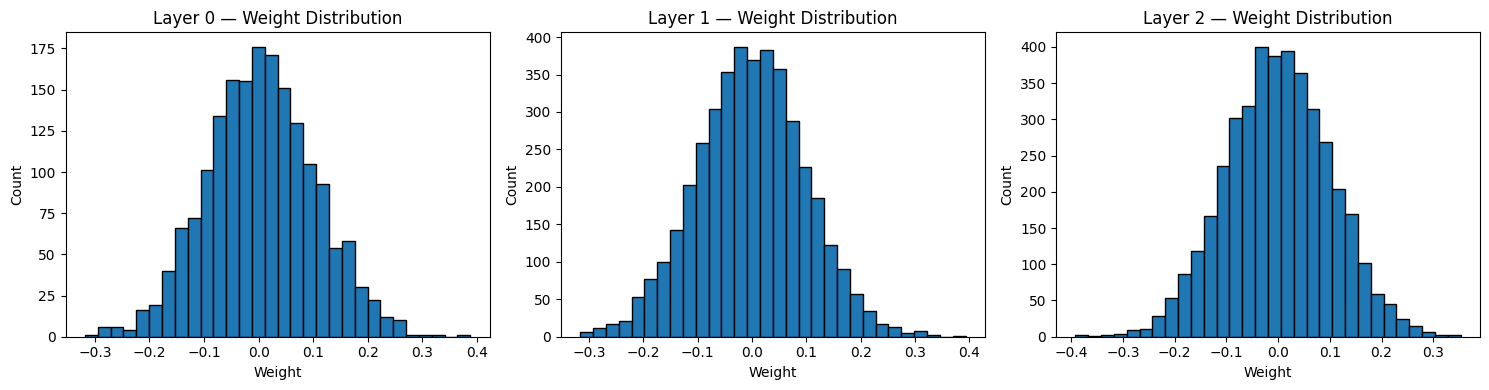

[lr=0.0005] Gradient Distribution


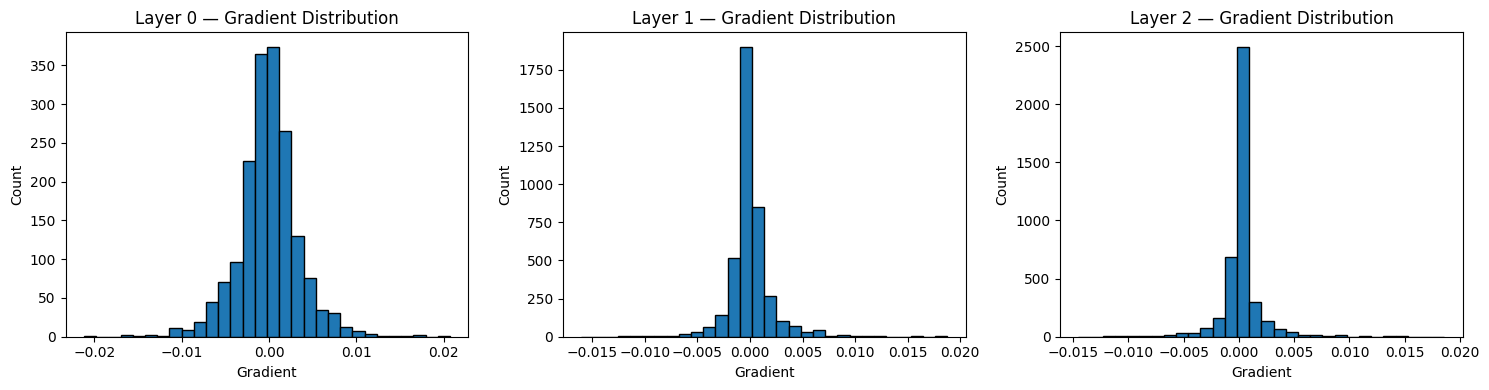


[lr=0.001] Weight Distribution


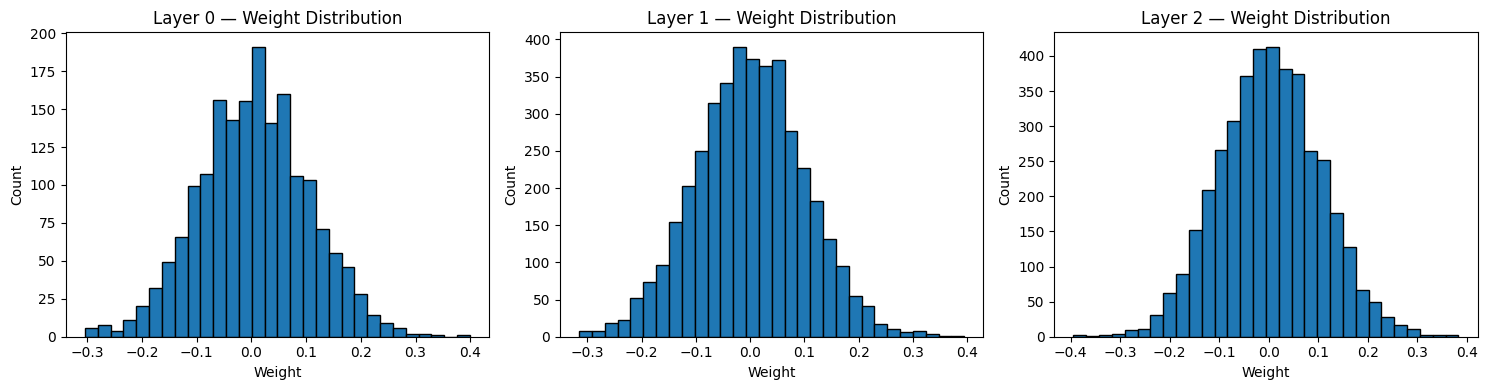

[lr=0.001] Gradient Distribution


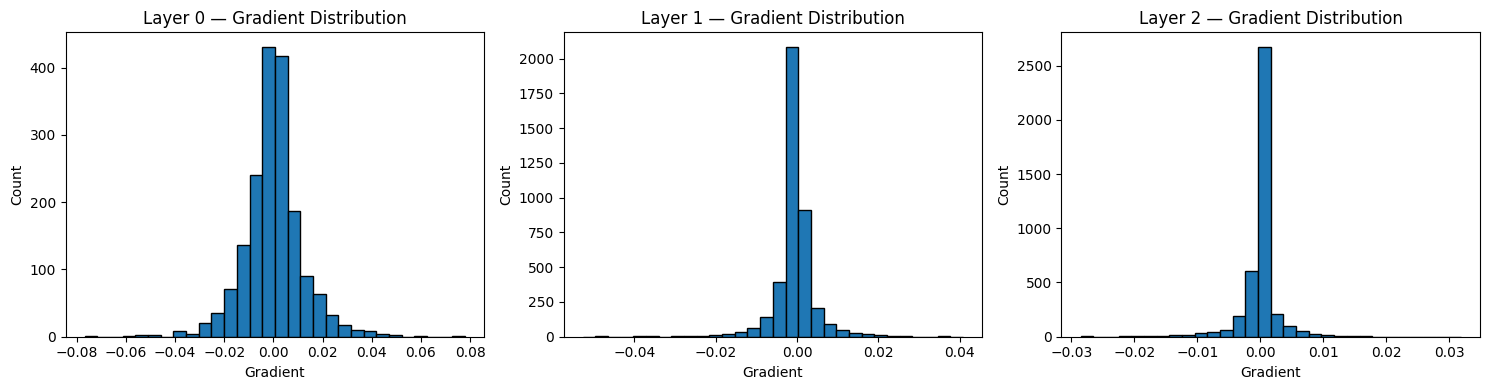


[lr=0.005] Weight Distribution


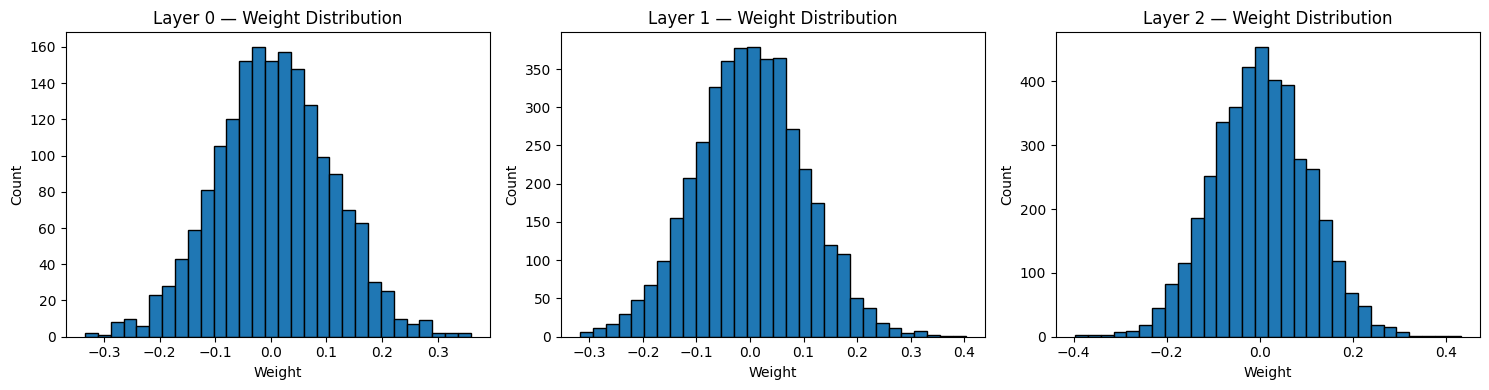

[lr=0.005] Gradient Distribution


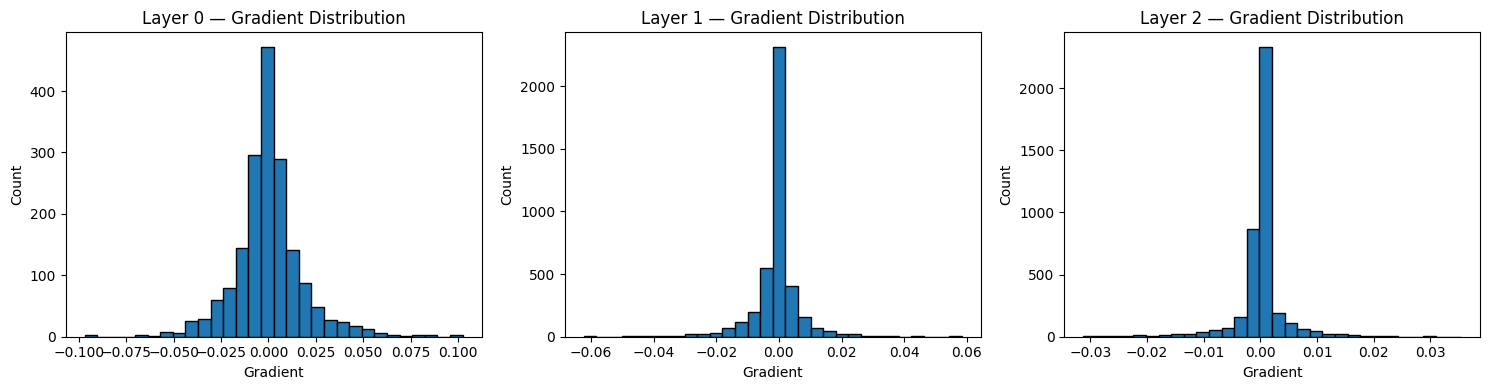

In [8]:
lr_settings = [0.0005, 0.001, 0.005]
lr_results = {}

for lr in lr_settings:
    key = f'lr={lr}'
    lr_results[key] = train_and_evaluate(
        hidden_dims=[64, 64, 64],
        hidden_activations=['ReLU', 'ReLU', 'ReLU'],
        learning_rate=lr,
        regularization='none',
        reg_lambda=0.0,
        epochs=BASE_MODEL_PARAMS['epochs'],
        batch_size=BASE_MODEL_PARAMS['batch_size'],
        random_state=RANDOM_STATE,
    )

print('=== Learning Rate Experiment Metrics ===')
display(metrics_table(lr_results))
print('\nSample prediksi:')
display(show_prediction_sample(lr_results, n=5))
plot_loss_curves(
    lr_results,
    'Learning Rate Comparison',
    save_path=PLOT_DIRS['learningrate'] / 'learning_rate_loss_curves.png',
)

plot_distribution_comparison(
    lr_results,
    layer_indices=[0, 1, 2],
    title='Learning Rate - Weight & Gradient Distribution (Layers 0,1,2)',
    output_dir=PLOT_DIRS['learningrate'],
    file_prefix='learning_rate_layers012',
)

## 4) Pengaruh Regularisasi

Eksperimen masing-masing 1 kali:
- tanpa regularisasi,
- regularisasi L1,
- regularisasi L2.

Dibandingkan: prediksi akhir, train/val loss, distribusi bobot dan gradien.

=== Regularization Experiment Metrics ===


,setting,accuracy,precision,recall,f1
0,none,0.7475,0.754558,0.874086,0.809936
1,l2,0.7215,0.701314,0.953696,0.808262
2,l1,0.6155,0.615500,1.000000,0.761993



Sample prediksi:


,y_true,pred_none,pred_l1,pred_l2
0,0,0,1,1
1,0,0,1,1
2,0,1,1,1
3,0,0,1,1
4,1,1,1,1


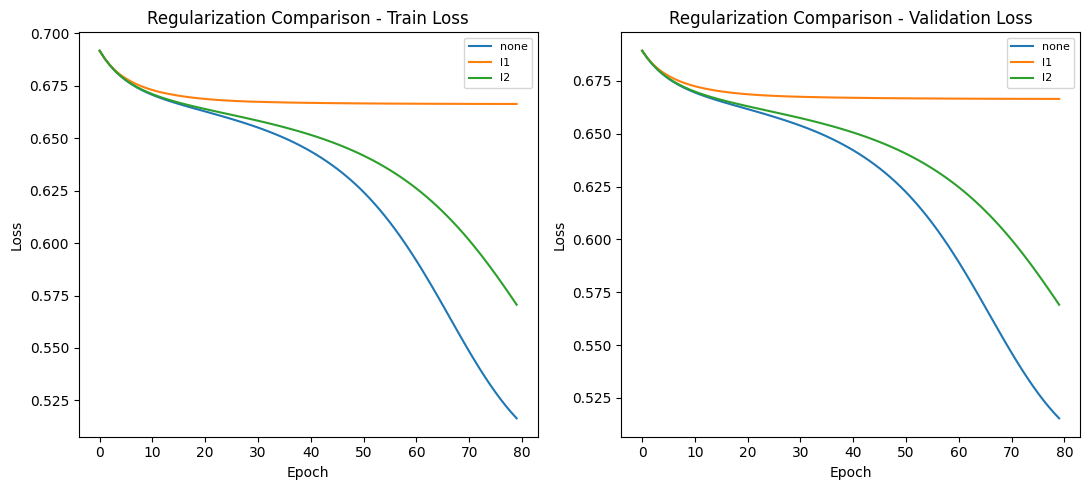

=== Regularization - Weight & Gradient Distribution (Layers 0,1,2) ===

[none] Weight Distribution


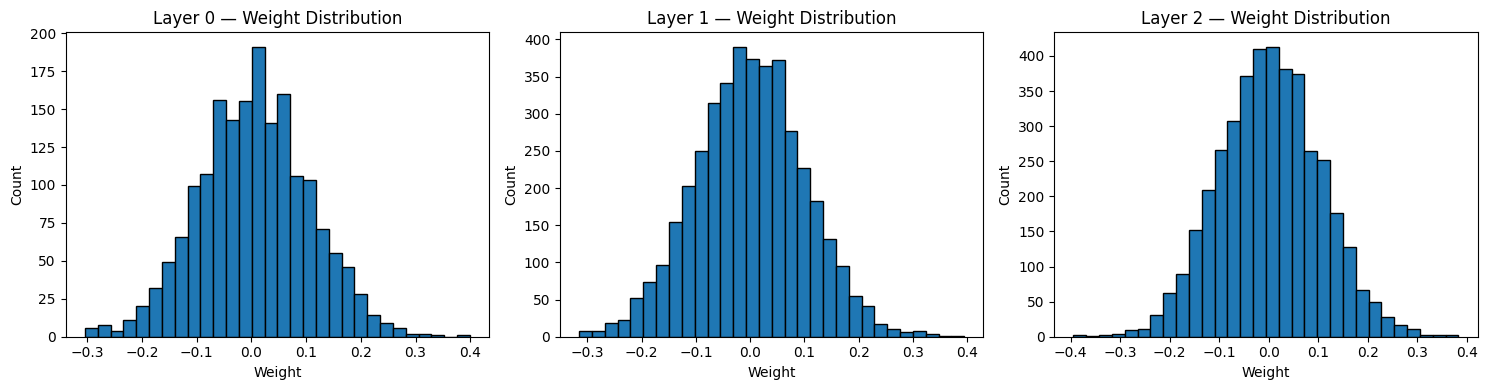

[none] Gradient Distribution


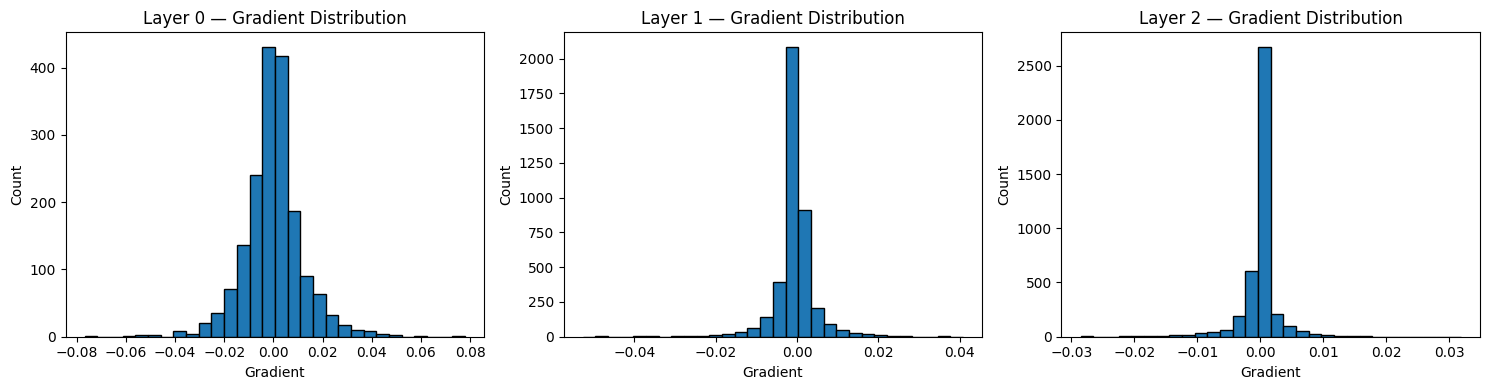


[l1] Weight Distribution


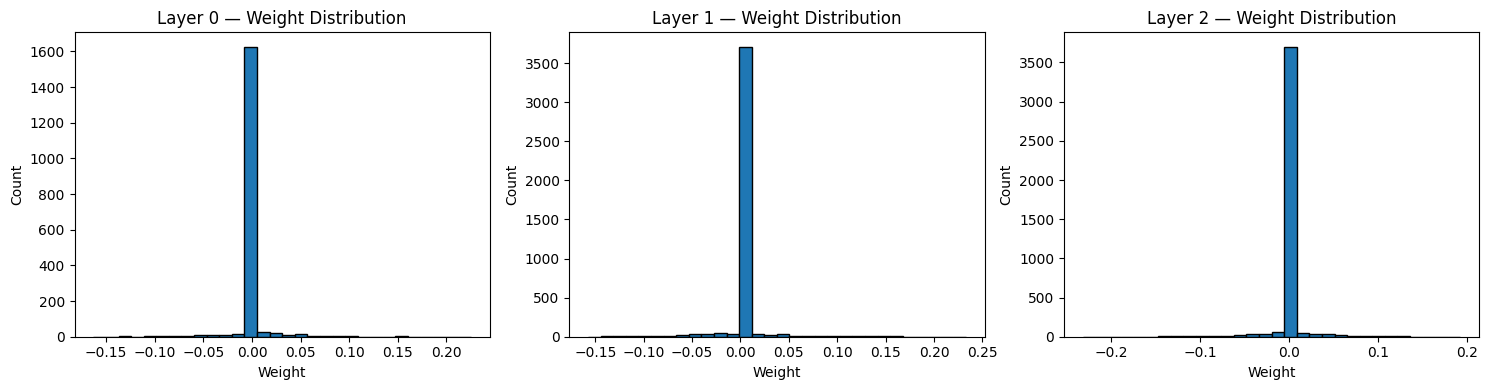

[l1] Gradient Distribution


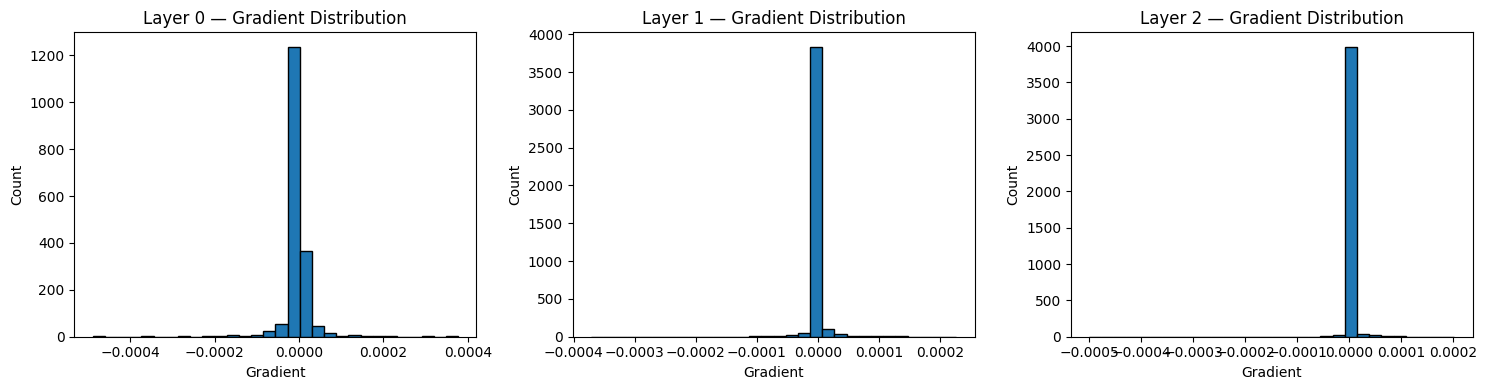


[l2] Weight Distribution


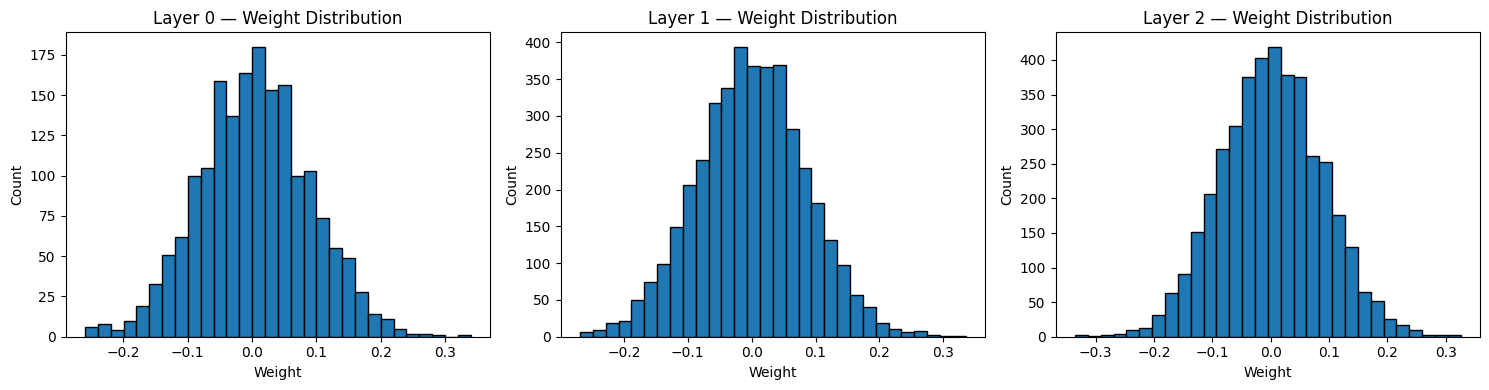

[l2] Gradient Distribution


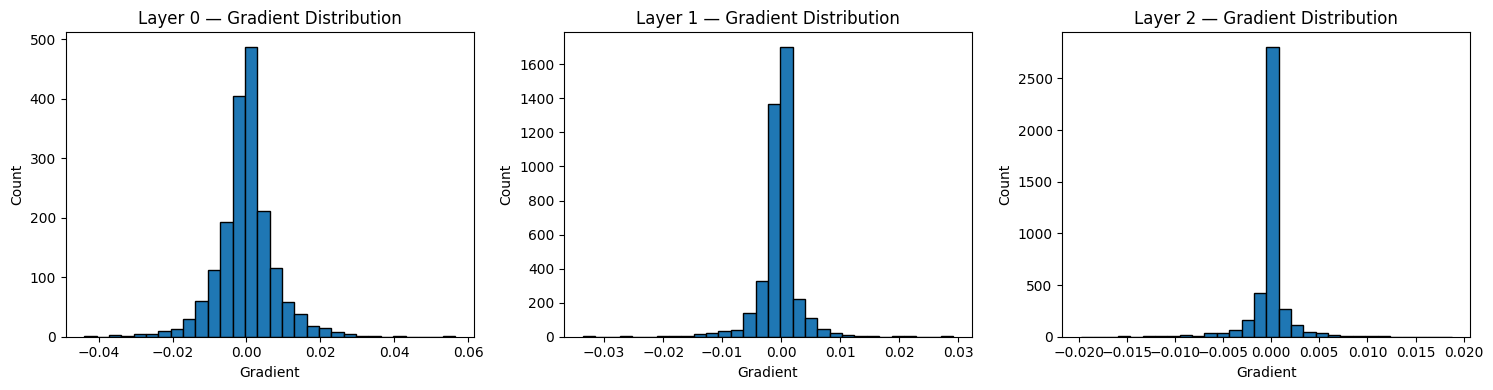

In [9]:
reg_settings = {
    'none': ('none', 0.0),
    'l1': ('l1', 0.01),
    'l2': ('l2', 0.01),
}

reg_results = {}
for name, (reg_type, reg_lambda) in reg_settings.items():
    reg_results[name] = train_and_evaluate(
        hidden_dims=[64, 64, 64],
        hidden_activations=['ReLU', 'ReLU', 'ReLU'],
        learning_rate=BASE_MODEL_PARAMS['learning_rate'],
        regularization=reg_type,
        reg_lambda=reg_lambda,
        epochs=BASE_MODEL_PARAMS['epochs'],
        batch_size=BASE_MODEL_PARAMS['batch_size'],
        random_state=RANDOM_STATE,
    )

print('=== Regularization Experiment Metrics ===')
display(metrics_table(reg_results))
print('\nSample prediksi:')
display(show_prediction_sample(reg_results, n=5))
plot_loss_curves(
    reg_results,
    'Regularization Comparison',
    save_path=PLOT_DIRS['regularization'] / 'regularization_ loss_curves.png',
)

plot_distribution_comparison(
    reg_results,
    layer_indices=[0, 1, 2],
    title='Regularization - Weight & Gradient Distribution (Layers 0,1,2)',
    output_dir=PLOT_DIRS['regularization'],
    file_prefix='regularization_layers012',
)

## 5) Perbandingan Inisialisasi Bobot

Eksperimen masing-masing 1 kali untuk setiap inisialisasi bobot dan perbandingan hasil yang didapatkan.

=== Initializer Experiment Metrics ===


,setting,accuracy,precision,recall,f1
0,XavierUniform,0.7480,0.773926,0.834281,0.802971
1,RandomNormal,0.7475,0.772932,0.835093,0.802811
2,XavierNormal,0.7435,0.770739,0.830219,0.799374
3,HeUniform,0.7380,0.765191,0.828595,0.795632
4,HeNormal,0.7320,0.760690,0.823721,0.790952
5,RandomUniform,0.6155,0.615500,1.000000,0.761993
6,Zeros,0.6155,0.615500,1.000000,0.761993



Sample prediksi:


,y_true,pred_Zeros,pred_RandomUniform,pred_RandomNormal,pred_XavierNormal,pred_XavierUniform,pred_HeUniform,pred_HeNormal
0,0,1,1,0,0,0,0,0
1,0,1,1,0,0,0,0,0
2,0,1,1,1,1,1,1,1
3,0,1,1,0,0,1,1,0
4,1,1,1,1,1,1,1,1


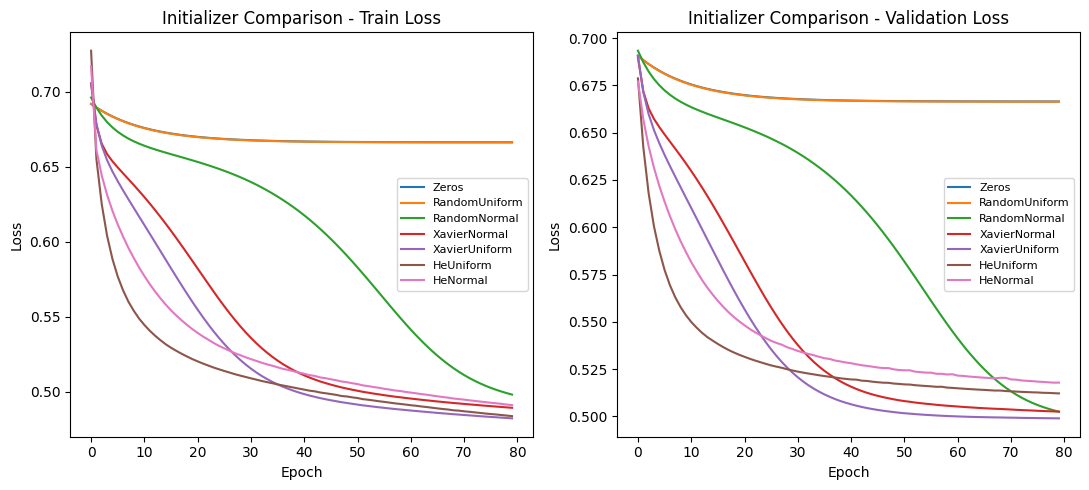

=== Initializer - Weight & Gradient Distribution (Layers 0,1,2) ===

[Zeros] Weight Distribution


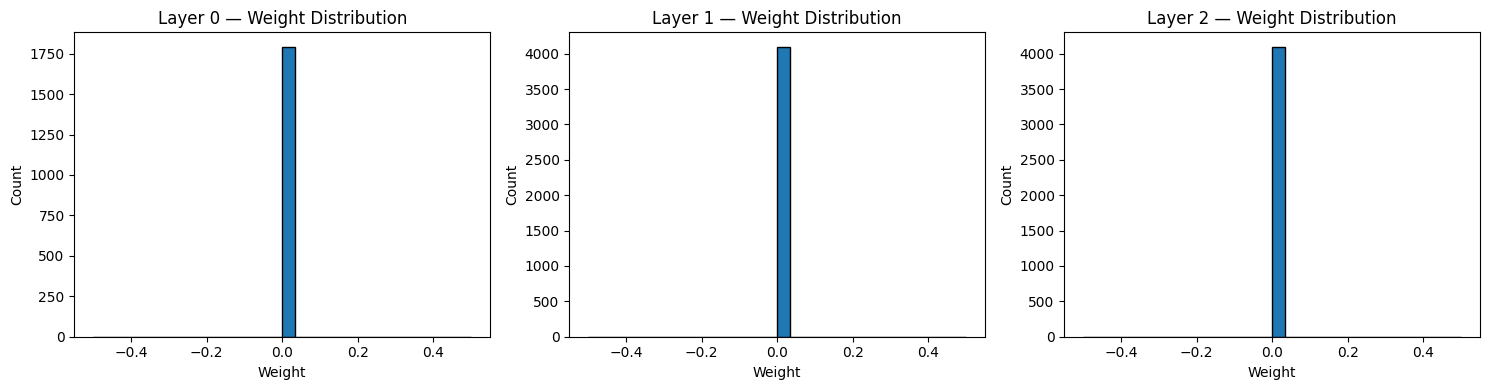

[Zeros] Gradient Distribution


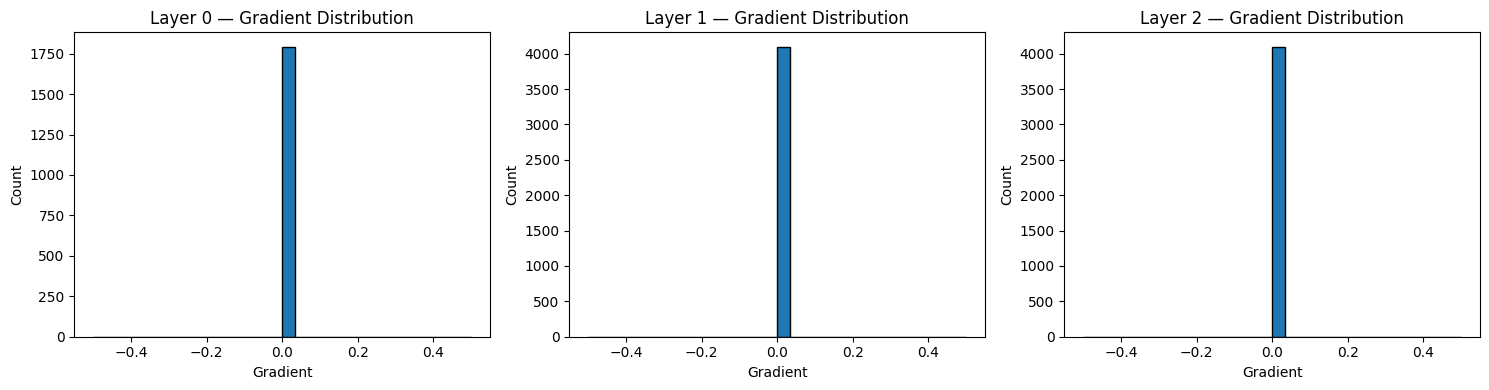


[RandomUniform] Weight Distribution


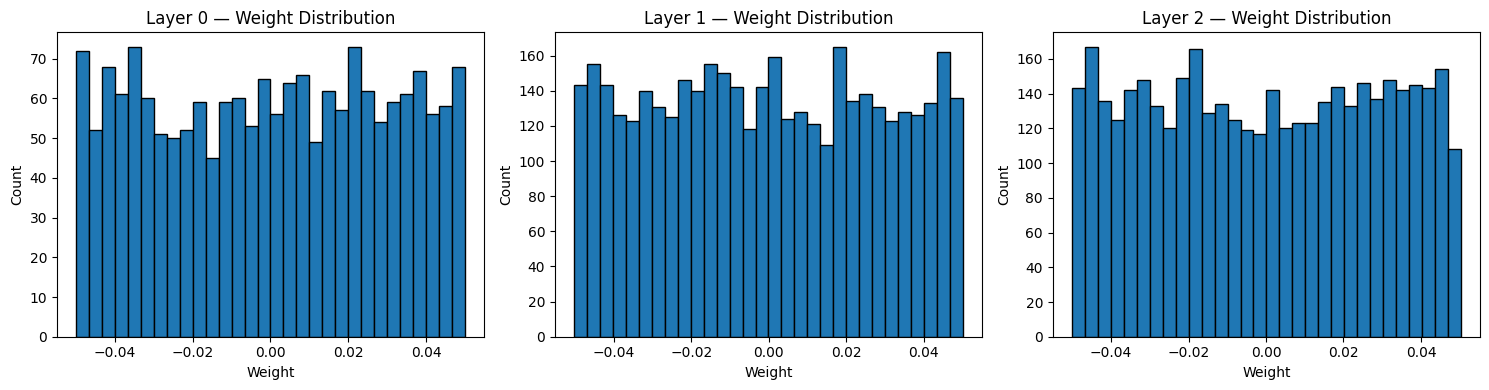

[RandomUniform] Gradient Distribution


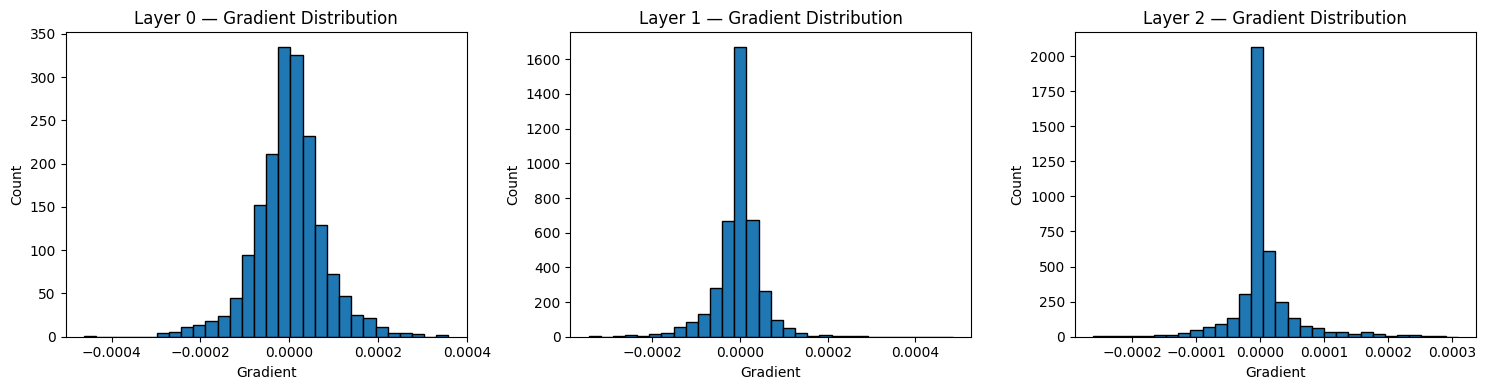


[RandomNormal] Weight Distribution


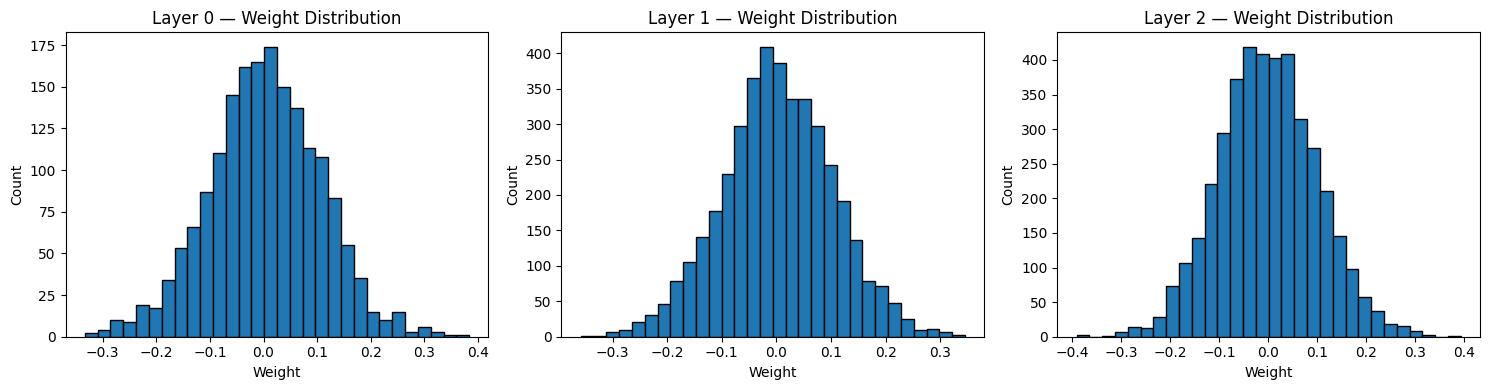

[RandomNormal] Gradient Distribution


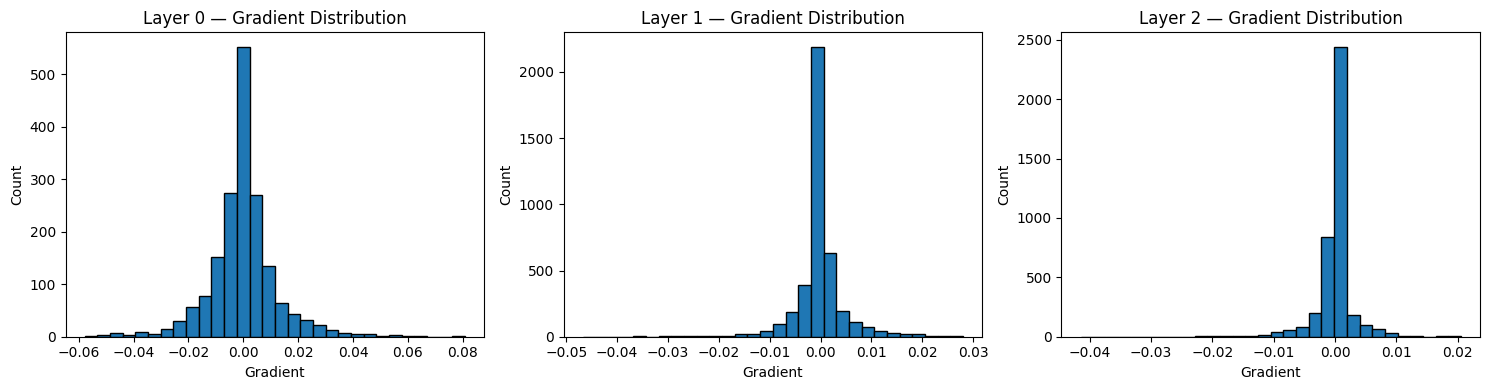


[XavierNormal] Weight Distribution


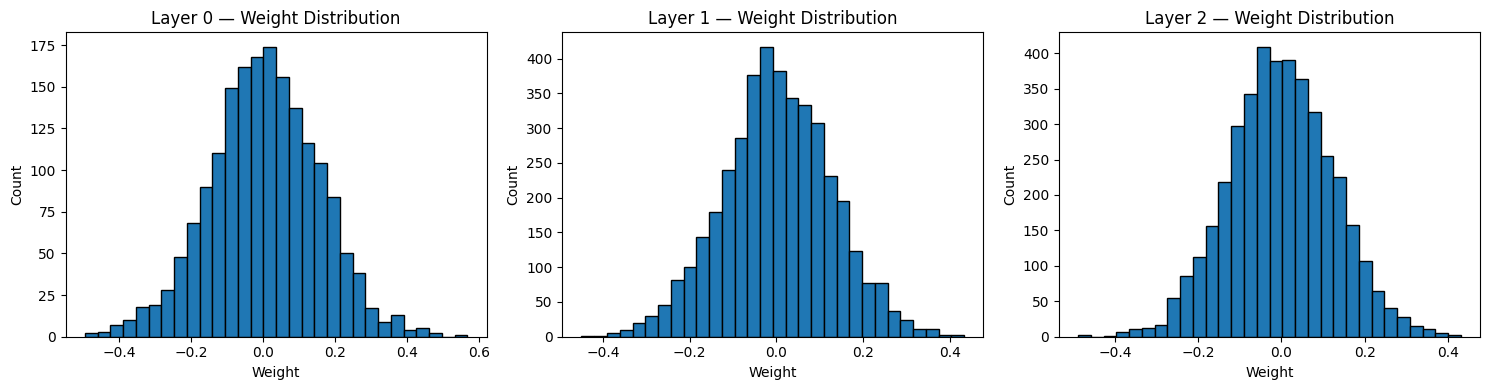

[XavierNormal] Gradient Distribution


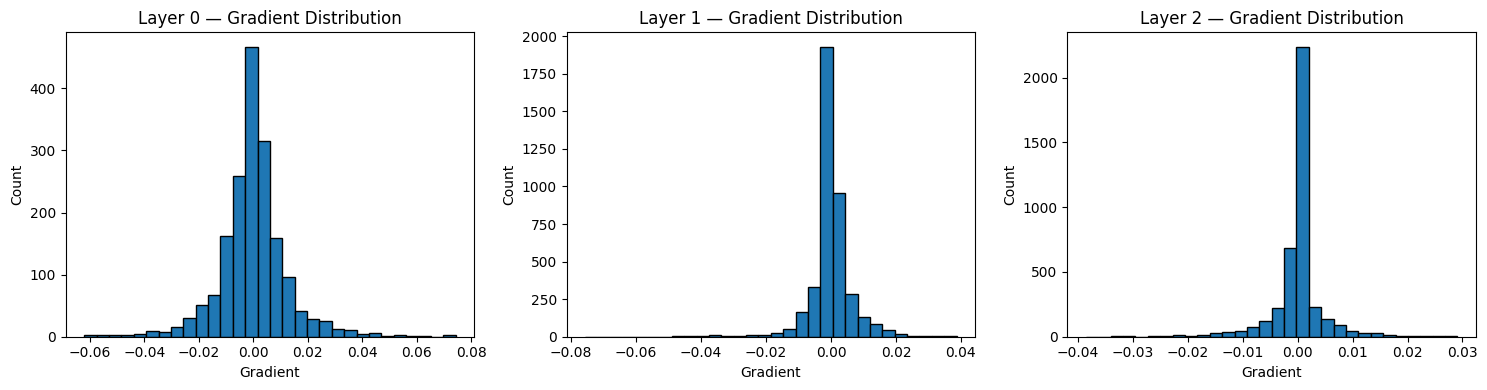


[XavierUniform] Weight Distribution


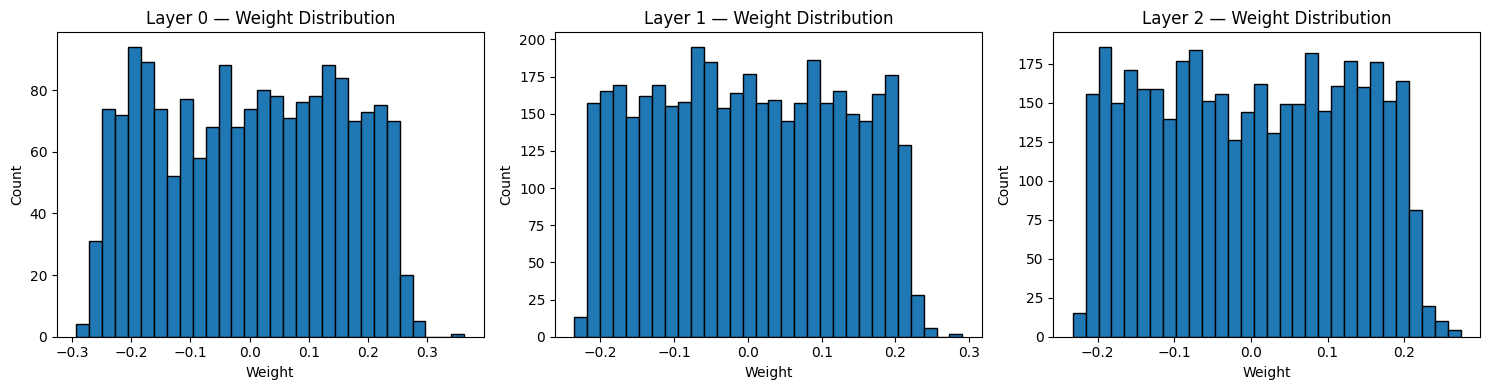

[XavierUniform] Gradient Distribution


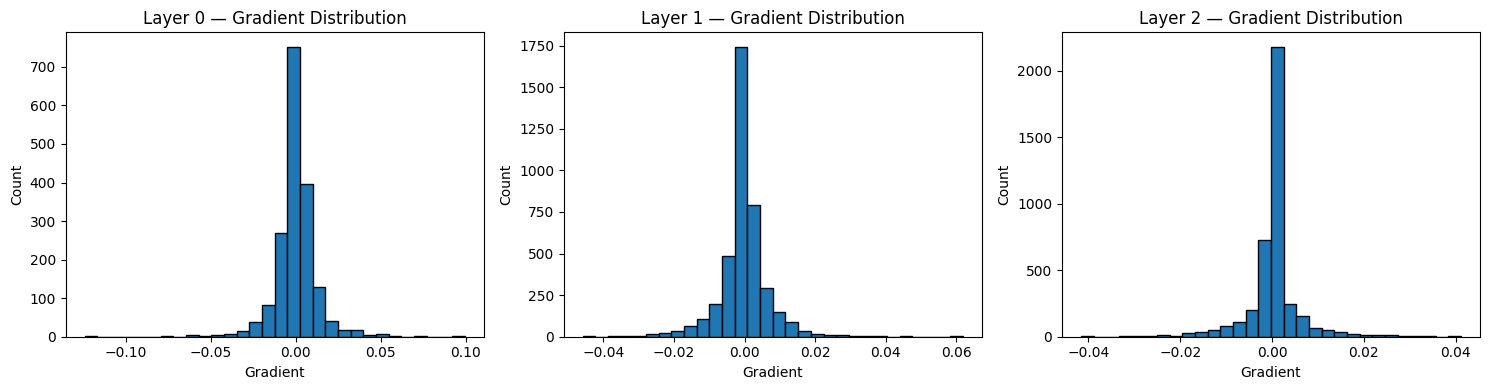


[HeUniform] Weight Distribution


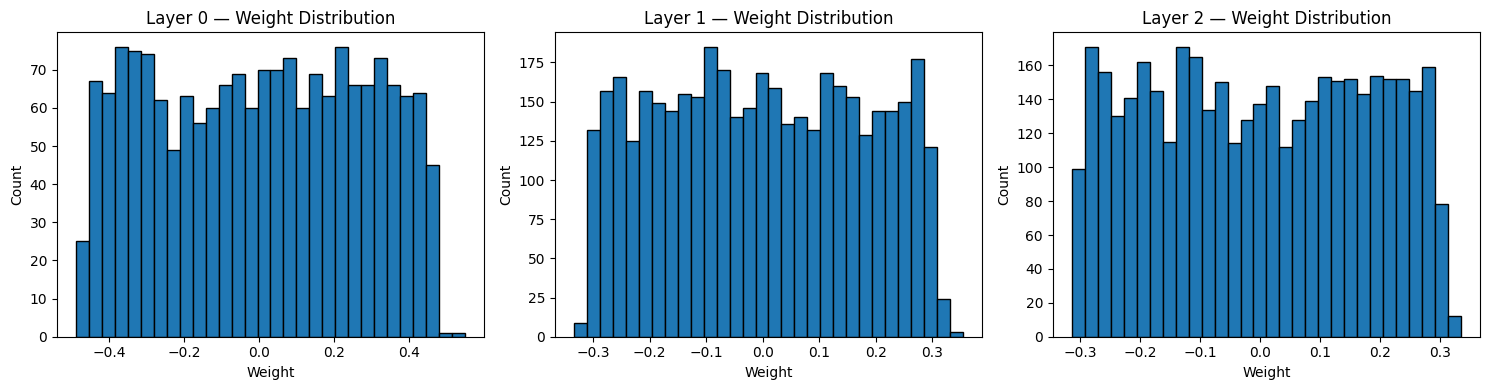

[HeUniform] Gradient Distribution


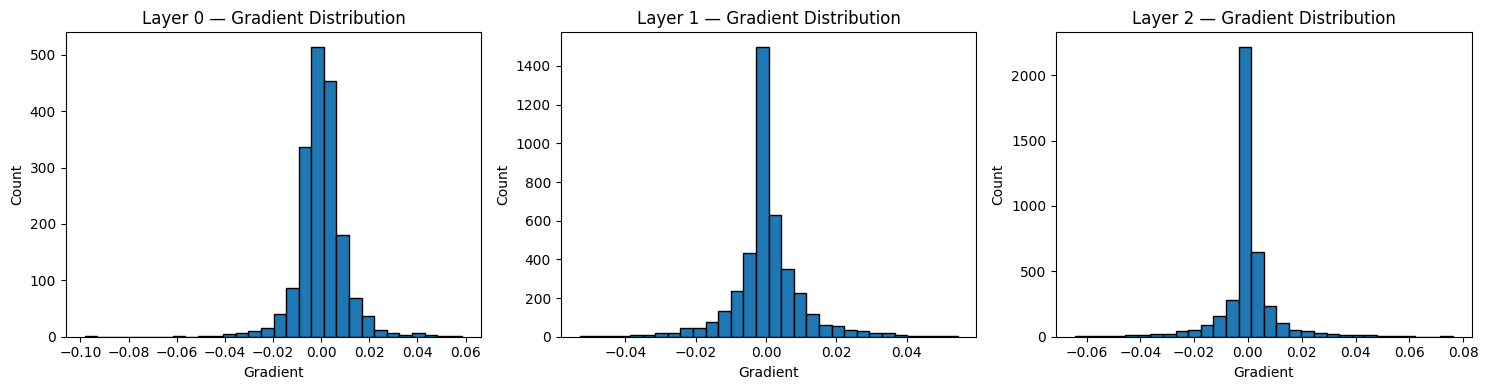


[HeNormal] Weight Distribution


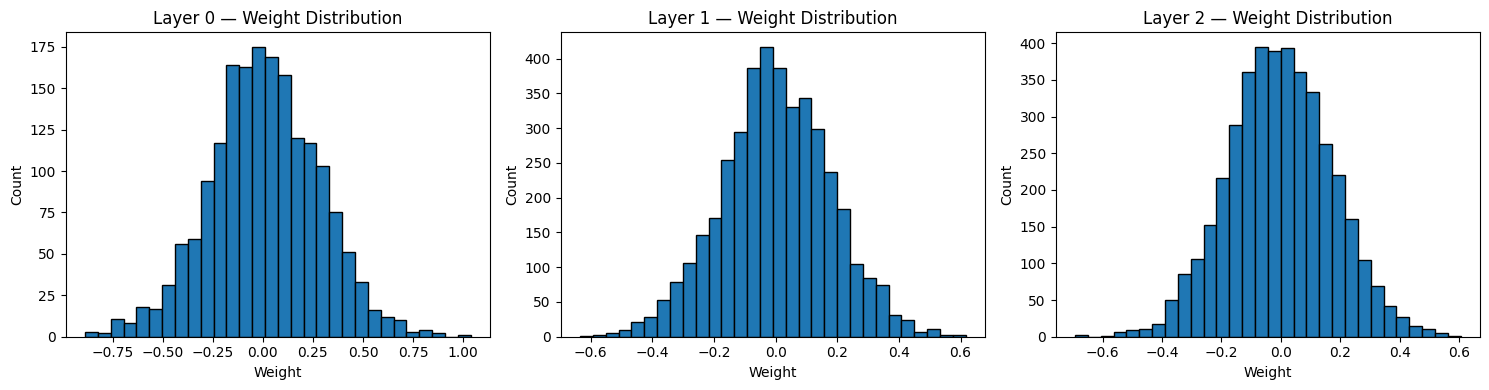

[HeNormal] Gradient Distribution


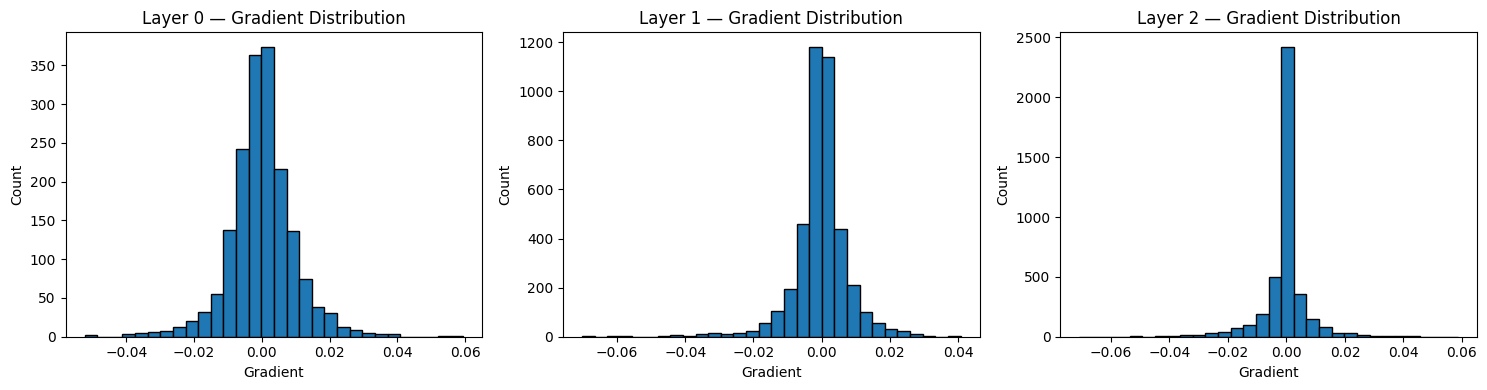

In [10]:
zero_initializer = ZerosInitializer()
random_uniform_initializer = RandomUniformInitializer(low=-0.05, high=0.05, seed=RANDOM_STATE)
random_normal_initializer = RandomNormalInitializer(mean=0.0, variance=0.01, seed=RANDOM_STATE)
xavier_normal_initializer = XavierNormalInitializer(seed=RANDOM_STATE)
xavier_uniform_initializer = XavierUniformInitializer(seed=RANDOM_STATE)
he_uniform_initializer = HeUniformInitializer(seed=RANDOM_STATE)
he_normal_initializer = HeNormalInitializer(seed=RANDOM_STATE)

initializer_settings = {
  'Zeros': zero_initializer,
  'RandomUniform': random_uniform_initializer,
  'RandomNormal': random_normal_initializer,
  'XavierNormal': xavier_normal_initializer,
  'XavierUniform': xavier_uniform_initializer,
  'HeUniform': he_uniform_initializer,
  'HeNormal': he_normal_initializer,
}

initializer_results = {}
for name, initializer in initializer_settings.items():
  initializer_results[name] = train_and_evaluate_initializer(
    initializer=initializer,
    hidden_dims=[64, 64, 64],
    hidden_activations=['ReLU', 'ReLU', 'ReLU'],
    learning_rate=BASE_MODEL_PARAMS['learning_rate'],
    regularization='none',
    reg_lambda=0.0,
    epochs=BASE_MODEL_PARAMS['epochs'],
    batch_size=BASE_MODEL_PARAMS['batch_size'],
    random_state=RANDOM_STATE,
  )

print('=== Initializer Experiment Metrics ===')
display(metrics_table(initializer_results))
print('\nSample prediksi:')
display(show_prediction_sample(initializer_results, n=5))
plot_loss_curves(
    initializer_results,
    'Initializer Comparison',
    save_path=PLOT_DIRS['initializer'] / 'initializer_loss_curves.png',
)

plot_distribution_comparison(
  initializer_results,
  layer_indices=[0, 1, 2],
  title='Initializer - Weight & Gradient Distribution (Layers 0,1,2)',
  output_dir=PLOT_DIRS['initializer'],
  file_prefix='initializer_layers012',
)

## 6) Uji Perbandingan dengan `sklearn` MLP

Satu kali pelatihan dengan hyperparameter yang sama untuk kedua model.
Yang dibandingkan: **hasil akhir prediksi**.

In [11]:
# Hyperparameter yang disamakan untuk kedua model
cmp_hidden_dims = [64, 64, 64]
cmp_learning_rate = 0.001
cmp_epochs = BASE_MODEL_PARAMS['epochs']
cmp_batch_size = BASE_MODEL_PARAMS['batch_size']

# Model custom FFNN
custom_result = train_and_evaluate(
    hidden_dims=cmp_hidden_dims,
    hidden_activations=['ReLU', 'ReLU', 'ReLU'],
    learning_rate=cmp_learning_rate,
    regularization='none',
    reg_lambda=0.0,
    epochs=cmp_epochs,
    batch_size=cmp_batch_size,
    random_state=RANDOM_STATE,
)

# Model sklearn MLP
sk_model = MLPClassifier(
    hidden_layer_sizes=tuple(cmp_hidden_dims),
    activation='relu',
    solver='sgd',
    alpha=0.0,
    learning_rate_init=cmp_learning_rate,
    batch_size=cmp_batch_size,
    max_iter=cmp_epochs,
    random_state=RANDOM_STATE,
)
sk_model.fit(X_train, y_train.ravel().astype(int))
sk_pred = sk_model.predict(X_test)

y_true_cmp = y_test.ravel().astype(int)

comparison_df = pd.DataFrame([
    {
        'model': 'Custom FFNN',
        'accuracy': accuracy_score(y_true_cmp, custom_result['y_pred']),
        'precision': precision_score(y_true_cmp, custom_result['y_pred'], zero_division=0),
        'recall': recall_score(y_true_cmp, custom_result['y_pred'], zero_division=0),
        'f1': f1_score(y_true_cmp, custom_result['y_pred'], zero_division=0),
    },
    {
        'model': 'sklearn MLPClassifier',
        'accuracy': accuracy_score(y_true_cmp, sk_pred),
        'precision': precision_score(y_true_cmp, sk_pred, zero_division=0),
        'recall': recall_score(y_true_cmp, sk_pred, zero_division=0),
        'f1': f1_score(y_true_cmp, sk_pred, zero_division=0),
    },
])

print('=== Perbandingan Prediksi Akhir ===')
display(comparison_df)

pred_compare_sample = pd.DataFrame({
    'y_true': y_true_cmp[:5],
    'pred_custom_ffnn': custom_result['y_pred'][:5],
    'pred_sklearn_mlp': sk_pred[:5],
})
print('\nSample prediksi:')
display(pred_compare_sample)

print('\nClassification report sklearn model:')
print(classification_report(y_true_cmp, sk_pred, zero_division=0))

=== Perbandingan Prediksi Akhir ===


c:\Users\MarkIIA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (80) reached and the optimization hasn't converged yet.
  warnings.warn(


,model,accuracy,precision,recall,f1
0,Custom FFNN,0.7475,0.754558,0.874086,0.809936
1,sklearn MLPClassifier,0.7250,0.773934,0.781478,0.777688



Sample prediksi:


,y_true,pred_custom_ffnn,pred_sklearn_mlp
0,0,0,0
1,0,0,1
2,0,1,0
3,0,0,0
4,1,1,1



Classification report sklearn model:
              precision    recall  f1-score   support

           0       0.64      0.63      0.64       769
           1       0.77      0.78      0.78      1231

    accuracy                           0.72      2000
   macro avg       0.71      0.71      0.71      2000
weighted avg       0.72      0.72      0.72      2000



## 7) Perbandingan Pengaruh RMSNorm

Satu kali pelatihan dengan hyperparameter yang sama untuk kedua model.

,model,accuracy,precision,recall,f1
0,Base FFNN,0.7475,0.754558,0.874086,0.809936
1,RMSNorm FFNN,0.7455,0.775152,0.826158,0.799843


Classification report base model: 
              precision    recall  f1-score   support

           0       0.73      0.54      0.62       769
           1       0.75      0.87      0.81      1231

    accuracy                           0.75      2000
   macro avg       0.74      0.71      0.72      2000
weighted avg       0.75      0.75      0.74      2000

Classification report RMSNorm model: 
              precision    recall  f1-score   support

           0       0.69      0.62      0.65       769
           1       0.78      0.83      0.80      1231

    accuracy                           0.75      2000
   macro avg       0.73      0.72      0.73      2000
weighted avg       0.74      0.75      0.74      2000



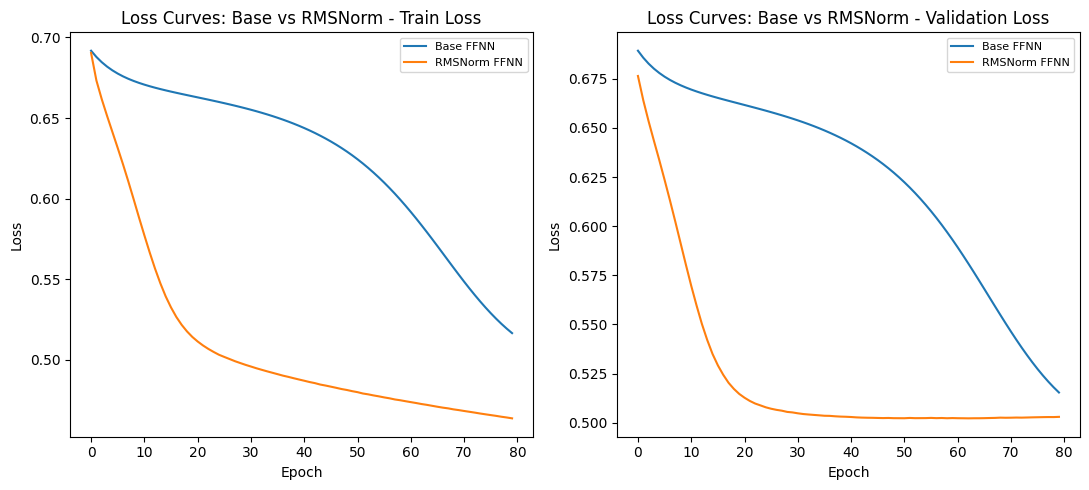

=== RMSNorm vs Base Model - Weight & Gradient Distribution (Layers 0,1,2) ===

[Base FFNN] Weight Distribution


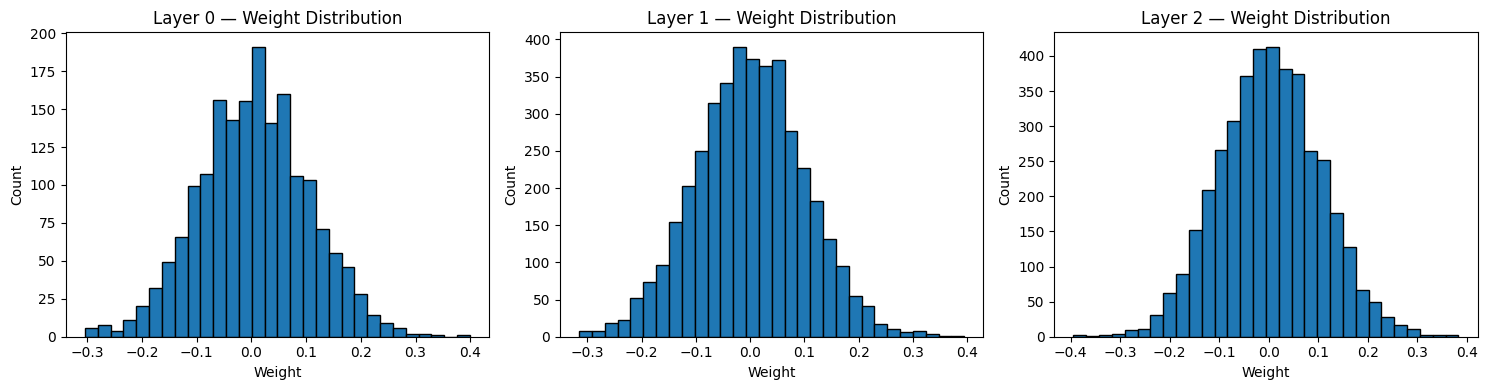

[Base FFNN] Gradient Distribution


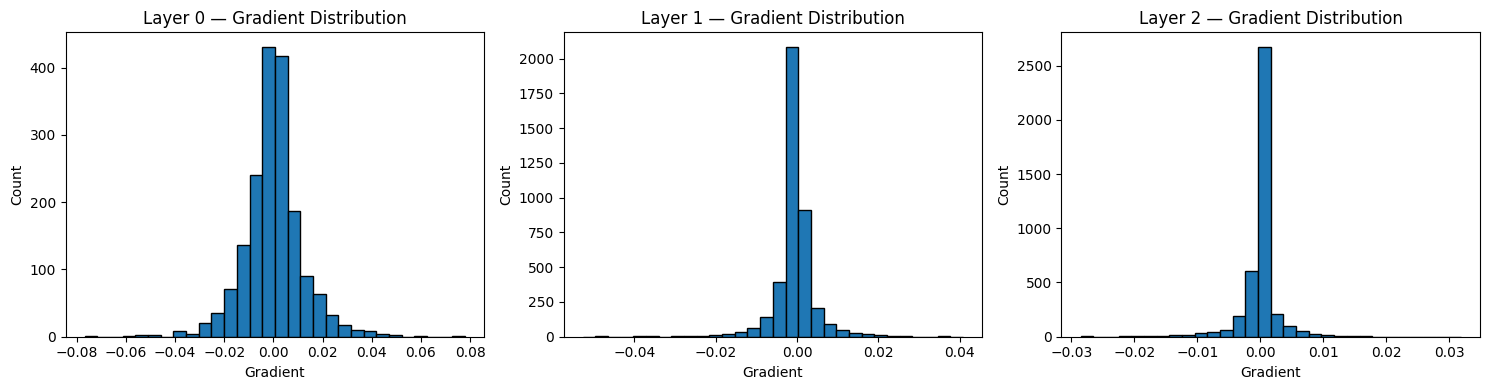


[RMSNorm FFNN] Weight Distribution


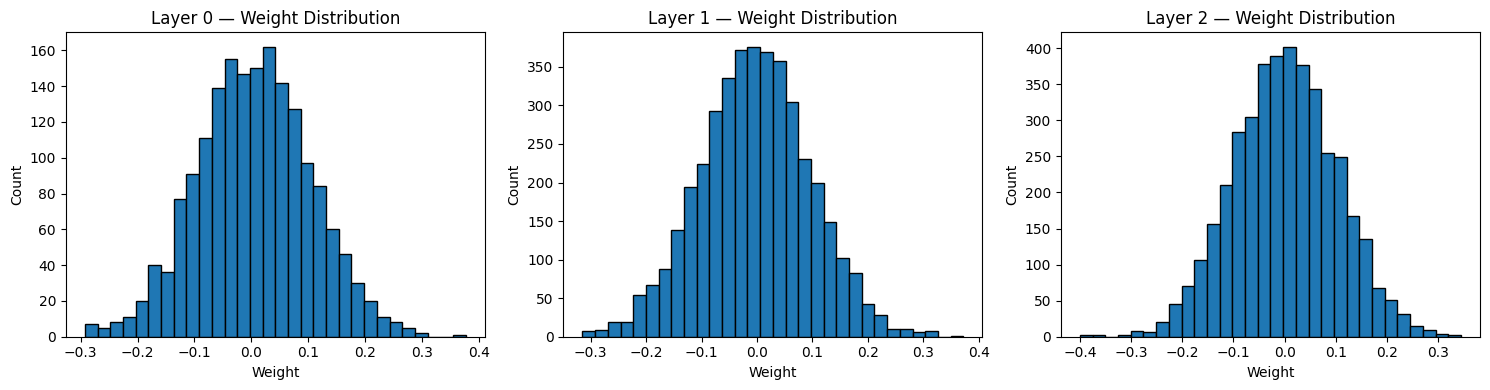

[RMSNorm FFNN] Gradient Distribution


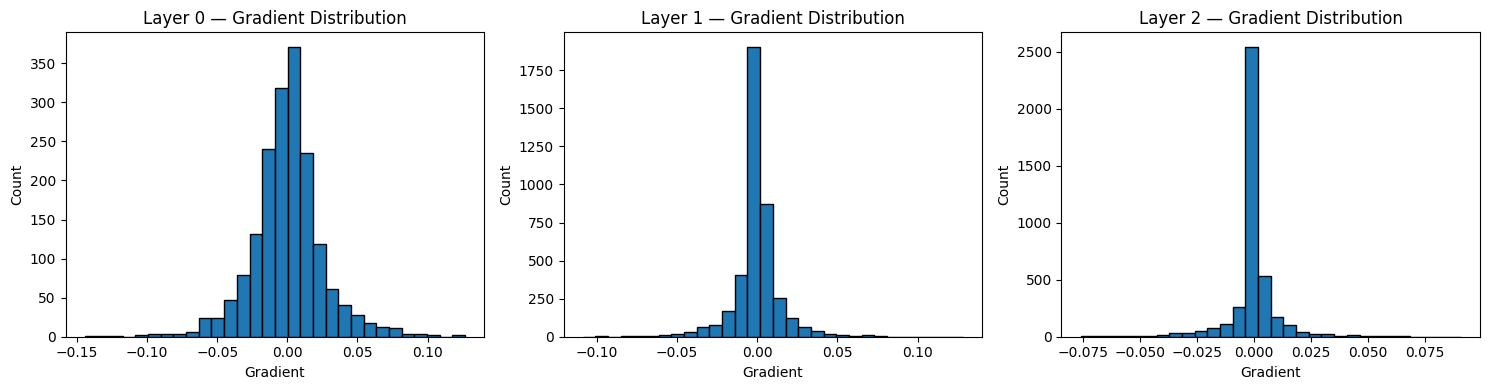

In [13]:
base_model_results = train_and_evaluate(
  hidden_dims=[64, 64, 64],
  hidden_activations=['ReLU', 'ReLU', 'ReLU'],
  learning_rate=BASE_MODEL_PARAMS['learning_rate'],
  regularization='none',
  reg_lambda=0.0,
  epochs=BASE_MODEL_PARAMS['epochs'],
  batch_size=BASE_MODEL_PARAMS['batch_size'],
  random_state=RANDOM_STATE,
)

rms_model_results = train_and_evaluate(
  hidden_dims=[64, 64, 64],
  hidden_activations=['ReLU', 'ReLU', 'ReLU'],
  output_activation=DEFAULT_OUTPUT_ACTIVATION,
  learning_rate=BASE_MODEL_PARAMS['learning_rate'],
  regularization='none',
  reg_lambda=0.0,
  epochs=BASE_MODEL_PARAMS['epochs'],
  batch_size=BASE_MODEL_PARAMS['batch_size'],
  random_state=RANDOM_STATE,
  rmsnorm=True,
)

y_true_cmp = y_test.ravel().astype(int)

comparison_df = pd.DataFrame([
  {
    'model': 'Base FFNN',
    'accuracy': accuracy_score(y_true_cmp, base_model_results['y_pred']),
    'precision': precision_score(y_true_cmp, base_model_results['y_pred'], zero_division=0),
    'recall': recall_score(y_true_cmp, base_model_results['y_pred'], zero_division=0),
    'f1': f1_score(y_true_cmp, base_model_results['y_pred'], zero_division=0),
  },
  {
    'model': 'RMSNorm FFNN',
    'accuracy': accuracy_score(y_true_cmp, rms_model_results['y_pred']),
    'precision': precision_score(y_true_cmp, rms_model_results['y_pred'], zero_division=0),
    'recall': recall_score(y_true_cmp, rms_model_results['y_pred'], zero_division=0),
    'f1': f1_score(y_true_cmp, rms_model_results['y_pred'], zero_division=0),
  },
])

display(comparison_df)

print("Classification report base model: ")
print(classification_report(y_true_cmp, base_model_results['y_pred'], zero_division=0))

print("Classification report RMSNorm model: ")
print(classification_report(y_true_cmp, rms_model_results['y_pred'], zero_division=0))

plot_loss_curves(
  {
    'Base FFNN': base_model_results,
    'RMSNorm FFNN': rms_model_results,
  },
  title='Loss Curves: Base vs RMSNorm',
  save_path=PLOT_DIRS['rmsnorm'] / 'rmsnorm_loss_curves.png',
)

plot_distribution_comparison(
  {
    'Base FFNN': base_model_results,
    'RMSNorm FFNN': rms_model_results,
  },
  layer_indices=[0, 1, 2],
  title='RMSNorm vs Base Model - Weight & Gradient Distribution (Layers 0,1,2)',
  output_dir=PLOT_DIRS['rmsnorm'],
  file_prefix='rmsnorm_comparison_layers012',
)